# HowFar — Validation Measurements (2026-05-25)

This notebook analyses three measurement sessions conducted on 2026-05-25:
- **Measurement 1:** Calibration / ALS cross-validation (1 Hz)
- **Measurement 2:** Distance validation sweep — white cardboard vs grey cloth (5 s)
- **Measurement 3:** Controlled ALS geometry test — four lighting conditions (5 s)

## NRS formula reference (exact, from NearworkRiskScoreCalculator.kt)

Per sample (only used if `0.0 < distanceCm <= 200.0`):

```
luxForWeight = 300.0  if lux is non-finite
             = 0.0    if lux < 0
             = lux    otherwise

diopters      = 100.0 / distanceCm
distanceWeight = 5.0  if distanceCm < 20
               = 2.5  if distanceCm < 30
               = 1.5  if distanceCm < 50
               = 1.0  otherwise

tierMultiplier(lux):
  lux <= 55    → 1.5
  lux <= 300   → 1.0
  lux <= 1000  → 0.8
  lux <= 3000  → 0.5
  lux <= 5000  → 0.35
  lux > 5000   → 0.2

lightWeight   = (1 / log10(luxForWeight + 10.0)) * tierMultiplier(luxForWeight)
instantNrs    = diopters * distanceWeight * lightWeight

NRS = mean(valid instantNrs) * duration_hours
```

Daily NRS: NRS computed per detected session (mean × session duration in hours), then summed across all sessions for that day — not averaged.

Low-light time tracking uses `lux < 55` (strict); NRS tier boundary uses `lux <= 55` (inclusive).

## Settings info

 - settingsVersion = 2024091701                                                                                                                                 
    Internal version of the settings structure expected by the firmware.                                                                                         
  - featureALS = 1                                                                                                                                               
    Ambient light sensor is enabled.                                                                                                                             
  - featureTOF = 1                                                                                                                                               
    Time-of-flight distance sensor is enabled.                                                                                                                   
  - featureDCDCSleep = 0                                                                                                                                         
    DC-DC sleep feature is disabled.                                                                                                                             
  - featureStorage = 1                                                                                                                                           
    Measurement storage on the device is enabled.                                                                                                                
  - flagEraseDatabase = 1                                                                                                                                        
    Device memory is cleared when this configuration is written.                                                                                                 
  - timestamp = computer time at configuration upload                                                                                                            
    The device clock is synchronized to the computer time when the config is sent.                                                                               
  - tofDistanceMode = 1                                                                                                                                          
    TOF sensor distance mode is set to mode 1.                                                                                                                   
  - tofTimingBudget = 20                                                                                                                                         
    TOF sensor timing budget is 20; this controls how long each distance reading can take.                                                                       
  - measurementInterval = 1                                                                                                                                      
    Measurements are taken every 1 second, which is 1 Hz.                                                                                                        
  - examinationIdentifier = OPTODATA                                                                                                                             
    The device uses OPTODATA as the UF2 filename/identifier.                                                                                                     
                                                                                                                                                                 
  For the calibration run, the key operational settings were:                                                                                                    
                                                                                                                                                                 
  - measurementInterval=1 for 1 Hz sampling                                                                                                                      
  - flagEraseDatabase=1 so the memory was cleared before use                     

### Measurement Protocol

The device was worn on glasses throughout. The reference meter was held adjacent to HowFar, directed the same way as gaze. The session has two parts: Part 1 with simultaneous reference lux readings (5 readings per location), Part 2 repeating the same locations without reference.

| # | Location | Part 1 time | Reference lux (5 readings) | Ref. mean | Part 2 time |
|---|---|---|---|---|---|
| 1 | Roof window (my room) | 16:30–16:32 | 78000 / 74900 / 73200 / 73300 / 73800 | 74640 | 16:39–16:41 |
| 2 | Bed (my room) | 16:32–16:33 | 394 / 393 / 393 / 392 / 389 | 392 | 16:41–16:43 |
| 3 | Sister's room | 16:33–16:35 | 1079 / 1088 / 1077 / 1049 / 1037 | 1066 | 16:43–16:45 |
| 4 | Living room sofa | 16:35 | 254 / 255 / 253 / 252 / 254 | 254 | 16:45–16:47 |
| 5 | Living room armchair | 16:35–16:36 | 357 / 345 / 338 / 339 / 342 | 344 | 16:47–16:49 |
| 6 | Kitchen (dining table + artificial) | 16:36–16:37 | 1284 / 1155 / 1140 / 1145 / 1144 | 1174 | 16:49–16:51 |
| 7 | Kitchen (window) | 16:37–16:38 | 327 / 322 / 333 / 350 / 347 | 336 | 16:51–16:53 |

Transition between parts: ~16:38–16:39. Session ended at 16:53 when device was connected to PC (face-down — last rows are artefact).

## 0. Setup & Imports
Mounts Google Drive, installs fonts, loads libraries, sets constants, and creates output directories.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

FILE_PATH = '/content/drive/MyDrive/Bachelor\'s Thesis/HowFar measurements/HowFar_kalibracja_25.05.2026.csv'

DIST_MIN_CM   = 10.0    # accepted distance range — lower bound (app)
DIST_MAX_CM   = 200.0   # accepted distance range — upper bound (app)
SMOOTH_WINDOW = 60      # rolling mean window (app)
LOW_LIGHT_LUX = 55.0    # low-light threshold, strict < (app)

import subprocess
subprocess.run(['apt-get', 'install', '-y', 'msttcorefonts'], capture_output=True)
import matplotlib.font_manager as fm
fm._load_fontmanager(try_read_cache=False)
plt.style.use("/content/drive/MyDrive/Bachelor's Thesis/howfar.mplstyle")
plt.rcParams['axes.titlepad'] = 10   # margin between title and plot
plt.rcParams['axes.labelpad'] = 8    # margin between axis label and tick values

C_HF  = '#51568D'  # Dusty Grape     — HowFar ALS raw signal
C_S   = '#546FA5'  # Smart Blue      — Sonel LXP-1 / white cardboard / valid TOF
C_T   = '#FC9494'  # Grapefruit Pink — errors, invalid readings, outliers ONLY
C_OUT = '#C9FCB1'  # Tea Green       — success / highlighted valid readings

LOCATION_COLORS = [
    '#546FA5', '#FC9494', '#4B3D6F', '#51568D', '#FCBD9F', '#FCE3A9',
    '#C9FCB1', '#B8FCED', '#BDE6FC', '#D2B8FF', '#C7C7FC', '#ADC9FF',
]
# Segment rotation — Grapefruit Pink reserved for errors/outliers only
SEG_COLORS = [c for c in LOCATION_COLORS if c != C_T]

In [3]:
import os
for _d in ['figs/ch4', 'figs/ch5', 'figs/app']:
    os.makedirs(_d, exist_ok=True)
print('Export directories ready.')

Export directories ready.


## 1. Data Loading & Inspection
Loads the 2026-05-25 ALS calibration session, checks for gaps and duplicates, and plots the raw ALS and ToF signals.

In [4]:
df = pd.read_csv(FILE_PATH, parse_dates=['datetime'])
df = df.sort_values('timestamp').reset_index(drop=True)

t_start    = df['datetime'].iloc[0]
t_end      = df['datetime'].iloc[-1]
duration_s = (t_end - t_start).total_seconds()
dt         = df['timestamp'].diff().dropna()
gaps       = df.loc[dt[dt > 1].index]
dups       = df.loc[dt[dt == 0].index]

print(f'Rows: {len(df)}  |  Columns: {list(df.columns)}')
print(f'Start: {t_start}  →  End: {t_end}  ({duration_s/60:.1f} min)')
print(f'Expected rows at 1 Hz: {int(duration_s)+1}  |  Actual: {len(df)}')
print()
print(f'Sampling — min: {dt.min():.0f}s  max: {dt.max():.0f}s  mean: {dt.mean():.4f}s')
print(f'Exactly 1s: {(dt==1).sum()}/{len(dt)} ({100*(dt==1).mean():.1f}%)')
print(f'Gaps (dt>1s): {len(gaps)}  |  Duplicates (dt=0s): {len(dups)}')
print()
df.info()

Rows: 1406  |  Columns: ['datetime', 'timestamp', 'alx_lx', 'tof_distance_mm']
Start: 2026-05-25 16:30:18  →  End: 2026-05-25 16:53:43  (23.4 min)
Expected rows at 1 Hz: 1406  |  Actual: 1406

Sampling — min: 1s  max: 1s  mean: 1.0000s
Exactly 1s: 1405/1405 (100.0%)
Gaps (dt>1s): 0  |  Duplicates (dt=0s): 0

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1406 entries, 0 to 1405
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   datetime         1406 non-null   datetime64[ns]
 1   timestamp        1406 non-null   int64         
 2   alx_lx           1406 non-null   float64       
 3   tof_distance_mm  1406 non-null   int64         
dtypes: datetime64[ns](1), float64(1), int64(2)
memory usage: 44.1 KB


In [5]:
tof    = df['tof_distance_mm']
tof_cm = tof / 10.0
valid  = (tof_cm > DIST_MIN_CM) & (tof_cm <= DIST_MAX_CM)

print('=== ALS (lux) ===')
print(df['alx_lx'].describe().round(2))
print(f'NaN: {df["alx_lx"].isna().sum()}  |  Negative: {(df["alx_lx"]<0).sum()}  |  Non-finite: {(~np.isfinite(df["alx_lx"])).sum()}')
print(f'Below {LOW_LIGHT_LUX} lux: {(df["alx_lx"]<LOW_LIGHT_LUX).sum()} samples ({100*(df["alx_lx"]<LOW_LIGHT_LUX).mean():.1f}%)')
print()
print('=== TOF (distance_mm) ===')
print(tof.describe().round(1))
print(f'Exactly 0 mm       : {(tof==0).sum()} ({100*(tof==0).mean():.1f}%)')
print(f'1–99 mm (rejected) : {((tof>0)&(tof<100)).sum()}')
print(f'100–2000 mm (valid): {valid.sum()} ({100*valid.mean():.1f}%)')
print(f'> 2000 mm          : {(tof>2000).sum()}')
print()
print('Valid TOF stats (cm):')
print(tof_cm[valid].describe().round(1))
print()
is_zero      = (tof == 0).astype(int)
runs         = is_zero.groupby((is_zero != is_zero.shift()).cumsum())
run_len      = runs.agg(['sum','count'])
zero_runs    = run_len[run_len['sum'] > 0]['count']
nonzero_runs = run_len[run_len['sum'] == 0]['count']
print('=== TOF=0 RUN ANALYSIS ===')
print(f'Zero-runs:    n={len(zero_runs)}  longest={zero_runs.max()}s  median={zero_runs.median():.0f}s')
print(f'Nonzero-runs: n={len(nonzero_runs)}  longest={nonzero_runs.max()}s  median={nonzero_runs.median():.0f}s')

=== ALS (lux) ===
count    1406.00
mean      210.57
std       211.39
min         5.76
25%        75.84
50%       160.64
75%       268.24
max      2201.60
Name: alx_lx, dtype: float64
NaN: 0  |  Negative: 0  |  Non-finite: 0
Below 55.0 lux: 246 samples (17.5%)

=== TOF (distance_mm) ===
count    1406.0
mean      495.1
std       498.5
min         0.0
25%         0.0
50%       414.0
75%      1020.8
max      1379.0
Name: tof_distance_mm, dtype: float64
Exactly 0 mm       : 621 (44.2%)
1–99 mm (rejected) : 8
100–2000 mm (valid): 777 (55.3%)
> 2000 mm          : 0

Valid TOF stats (cm):
count    777.0
mean      89.6
std       30.1
min       15.0
25%       72.7
50%       95.5
75%      111.4
max      137.9
Name: tof_distance_mm, dtype: float64

=== TOF=0 RUN ANALYSIS ===
Zero-runs:    n=97  longest=59s  median=3s
Nonzero-runs: n=97  longest=98s  median=2s


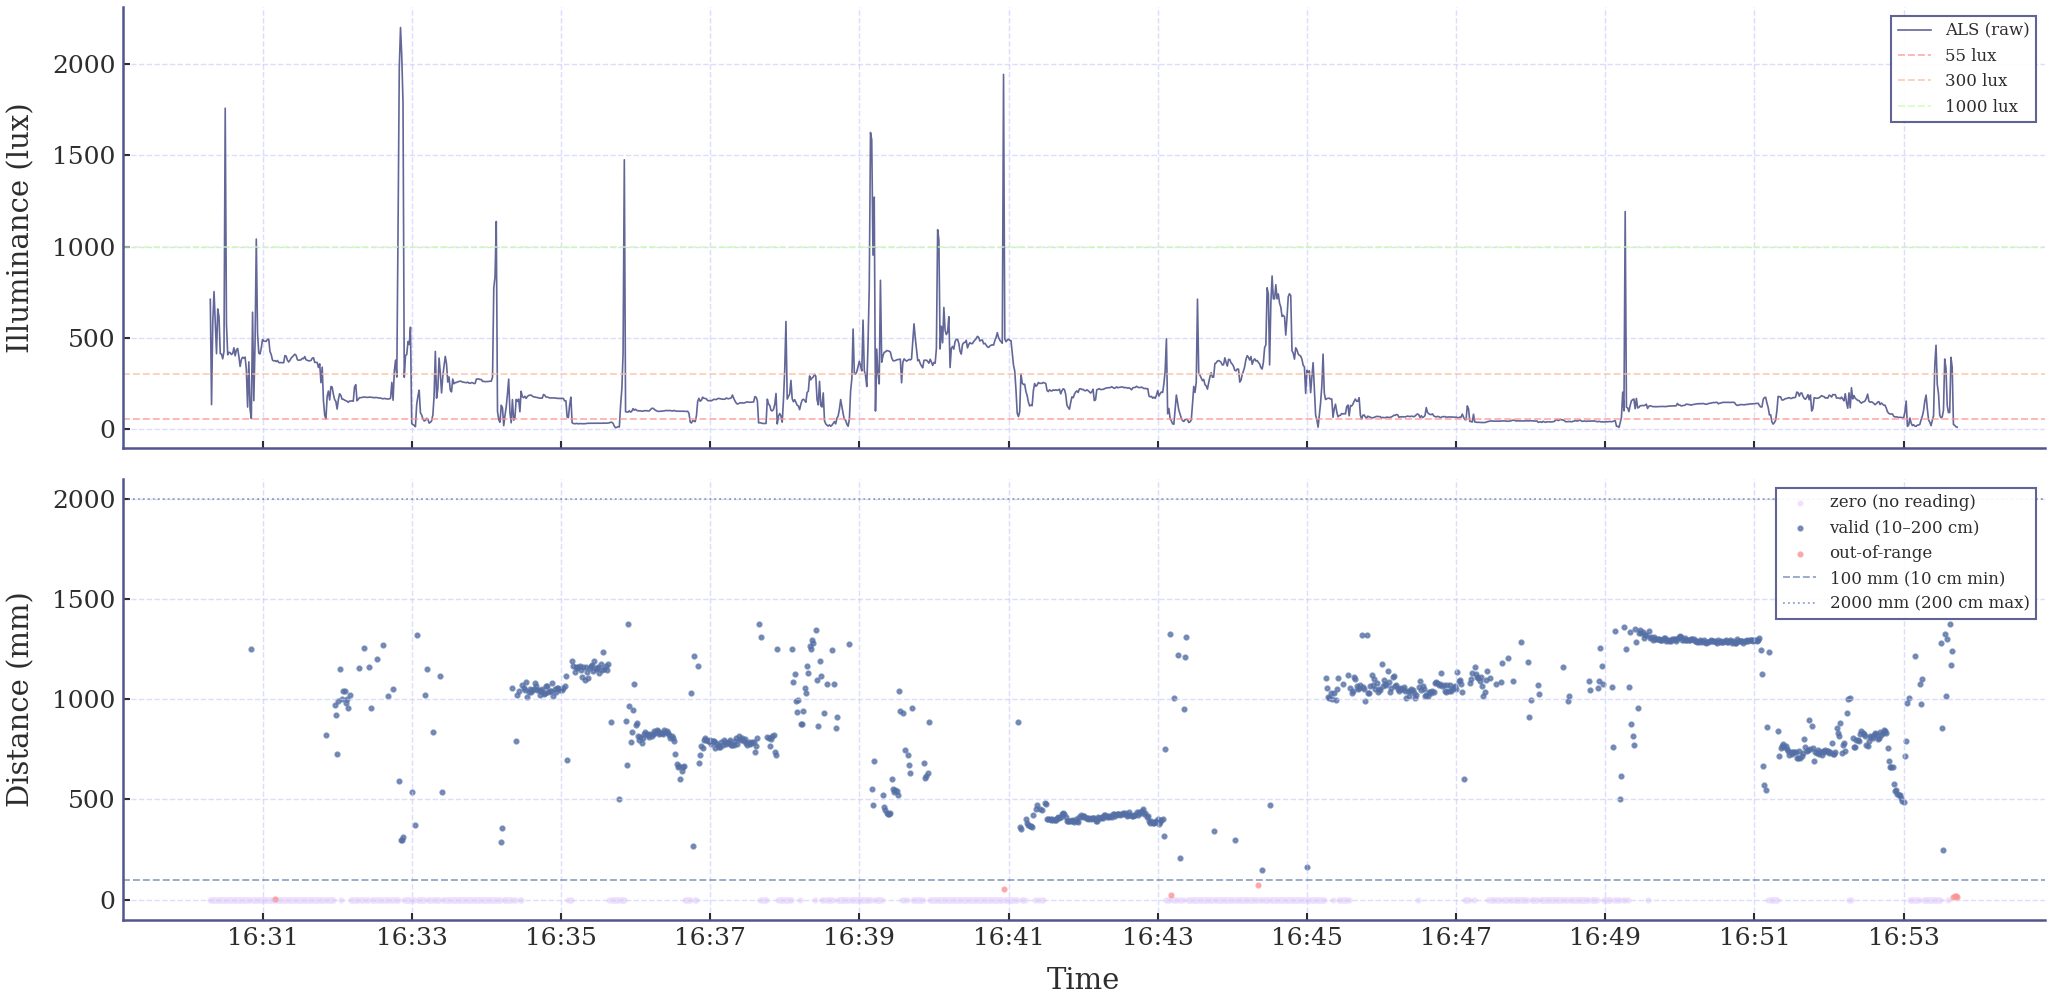

In [6]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

ax1.plot(df['datetime'], df['alx_lx'], color=C_HF, linewidth=0.8, alpha=0.9, label='ALS (raw)')
for y, col, lbl in [(55,C_T,'55 lux'),(300,'#FCBD9F','300 lux'),(1000,C_OUT,'1000 lux')]:
    ax1.axhline(y, color=col, linestyle='--', linewidth=0.9, alpha=0.7, label=lbl)
ax1.set_ylabel('Illuminance (lux)')
ax1.legend(loc='upper right', fontsize=8)

_zero_m1 = (tof == 0)
_oor_m1  = (~_zero_m1) & (~valid)
ax2.scatter(df.loc[_zero_m1, 'datetime'], tof[_zero_m1],  c='#EDDCFC', s=4, alpha=0.7, label='zero (no reading)')
ax2.scatter(df.loc[valid,    'datetime'], tof[valid],      c=C_S,       s=4, alpha=0.7, label='valid (10–200 cm)')
ax2.scatter(df.loc[_oor_m1,  'datetime'], tof[_oor_m1],   c=C_T,       s=4, alpha=0.7, label='out-of-range')
ax2.axhline(100,  color=C_S, linestyle='--', linewidth=0.9, alpha=0.6, label='100 mm (10 cm min)')
ax2.axhline(2000, color=C_S, linestyle=':',  linewidth=0.9, alpha=0.6, label='2000 mm (200 cm max)')
ax2.set_ylabel('Distance (mm)')
ax2.set_xlabel('Time')
ax2.legend(loc='upper right', fontsize=8)
ax2.xaxis.set_major_locator(mdates.MinuteLocator(interval=2))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.tight_layout()
plt.show()

In [7]:
submm = df[( tof > 0) & (tof < 100)][['datetime', 'tof_distance_mm', 'alx_lx']]
print('=== SUB-MINIMUM TOF READINGS (1–99 mm) ===')
print(submm.to_string(index=False))
print()

rolling_mean = df['alx_lx'].rolling(window=10, center=True, min_periods=1).mean()
rolling_std  = df['alx_lx'].rolling(window=10, center=True, min_periods=1).std()
spikes = df['alx_lx'] > (rolling_mean + 3 * rolling_std)
print(f'=== ALS SPIKES (>3σ above local rolling mean, window=10s) ===')
print(f'Spike count: {spikes.sum()} ({100*spikes.mean():.1f}%)')
print(f'Max spike value: {df.loc[spikes, "alx_lx"].max():.1f} lux')
print()

zero_mask    = tof == 0
print('=== TOF=0 vs LUX ===')
print(f'Mean lux when TOF=0:       {df.loc[zero_mask, "alx_lx"].mean():.1f}')
print(f'Mean lux when TOF valid:   {df.loc[valid, "alx_lx"].mean():.1f}')
print(f'Mean lux when TOF nonzero: {df.loc[~zero_mask, "alx_lx"].mean():.1f}')
print()
print('Lux percentiles when TOF=0:')
print(df.loc[zero_mask, 'alx_lx'].quantile([0.25, 0.5, 0.75, 0.95]).round(1))
print()
print('Lux percentiles when TOF valid:')
print(df.loc[valid, 'alx_lx'].quantile([0.25, 0.5, 0.75, 0.95]).round(1))
print()

usable = valid & ~spikes
print(f'=== USABLE SAMPLES (valid TOF + non-spike lux) ===')
print(f'{usable.sum()} / {len(df)} ({100*usable.mean():.1f}%)')

=== SUB-MINIMUM TOF READINGS (1–99 mm) ===
           datetime  tof_distance_mm  alx_lx
2026-05-25 16:31:10                5  374.08
2026-05-25 16:40:56               54 1944.32
2026-05-25 16:43:11               21   43.20
2026-05-25 16:44:21               72  363.84
2026-05-25 16:53:40               13   24.00
2026-05-25 16:53:41               17   19.20
2026-05-25 16:53:42               17   11.52
2026-05-25 16:53:43               13    8.96

=== ALS SPIKES (>3σ above local rolling mean, window=10s) ===
Spike count: 0 (0.0%)
Max spike value: nan lux

=== TOF=0 vs LUX ===
Mean lux when TOF=0:       279.1
Mean lux when TOF valid:   154.4
Mean lux when TOF nonzero: 156.4

Lux percentiles when TOF=0:
0.25     74.2
0.50    259.2
0.75    401.3
0.95    657.6
Name: alx_lx, dtype: float64

Lux percentiles when TOF valid:
0.25     78.1
0.50    139.5
0.75    173.1
0.95    322.4
Name: alx_lx, dtype: float64

=== USABLE SAMPLES (valid TOF + non-spike lux) ===
777 / 1406 (55.3%)


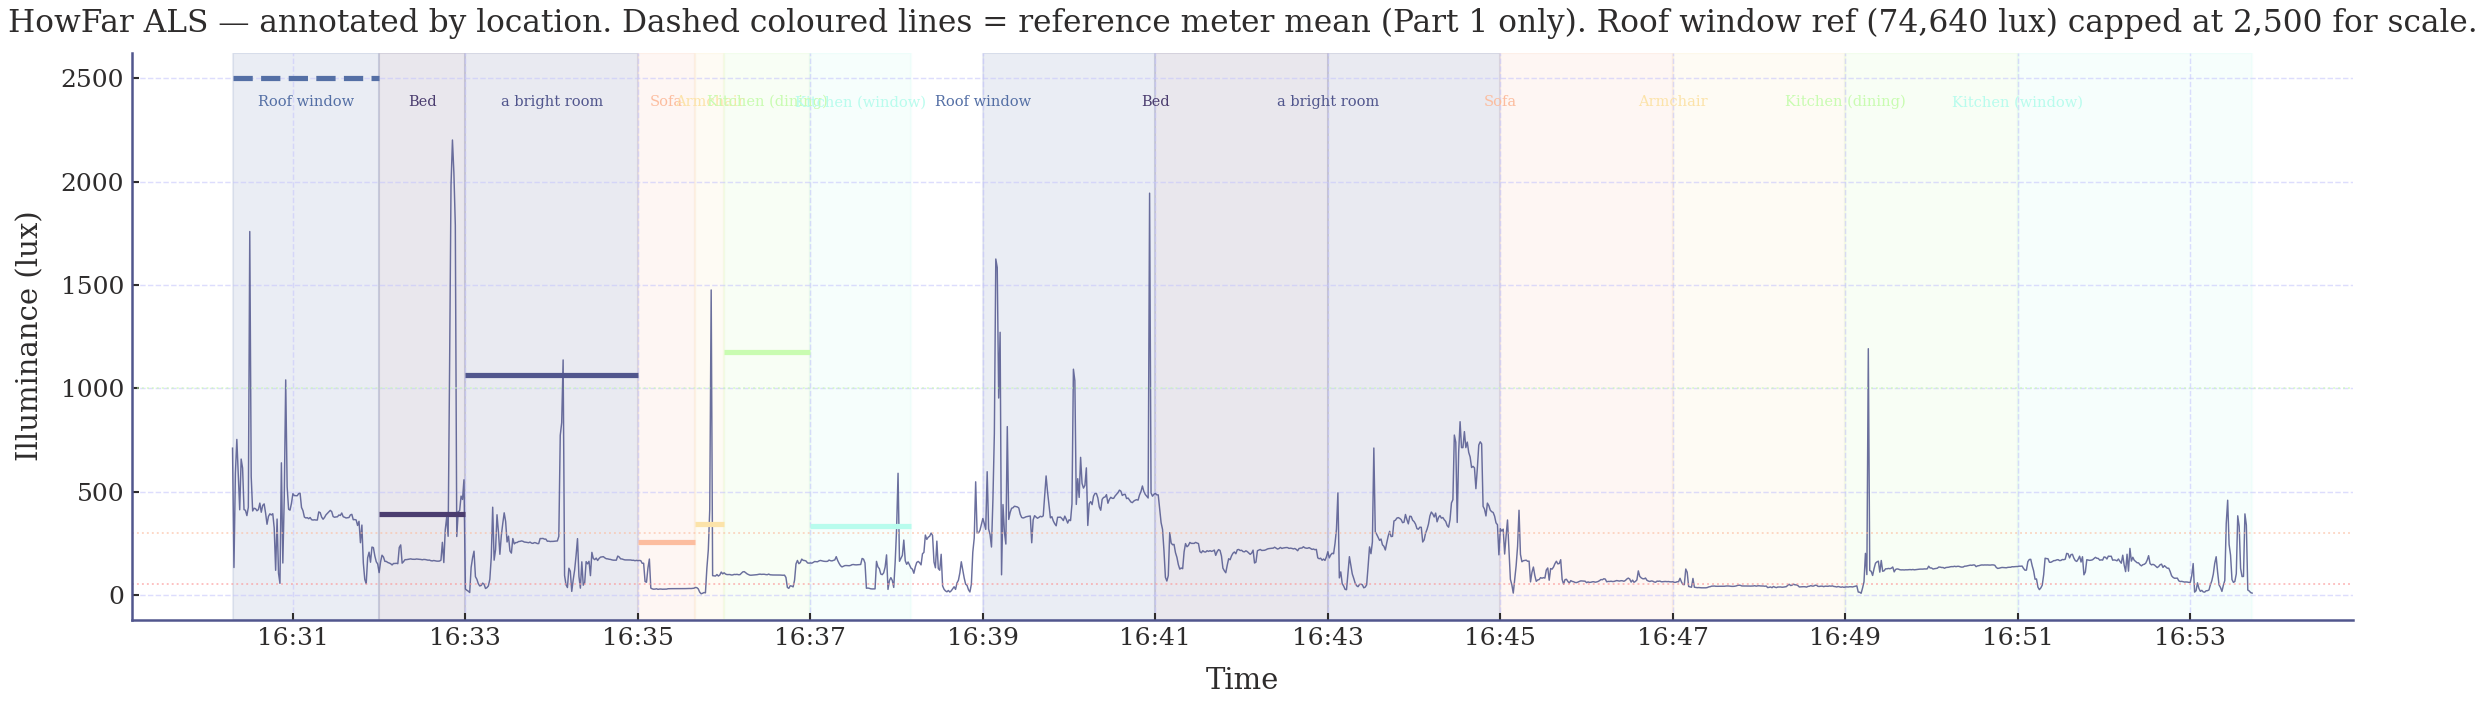

Saved: figs/ch4/fig_4_als_ratio.pdf


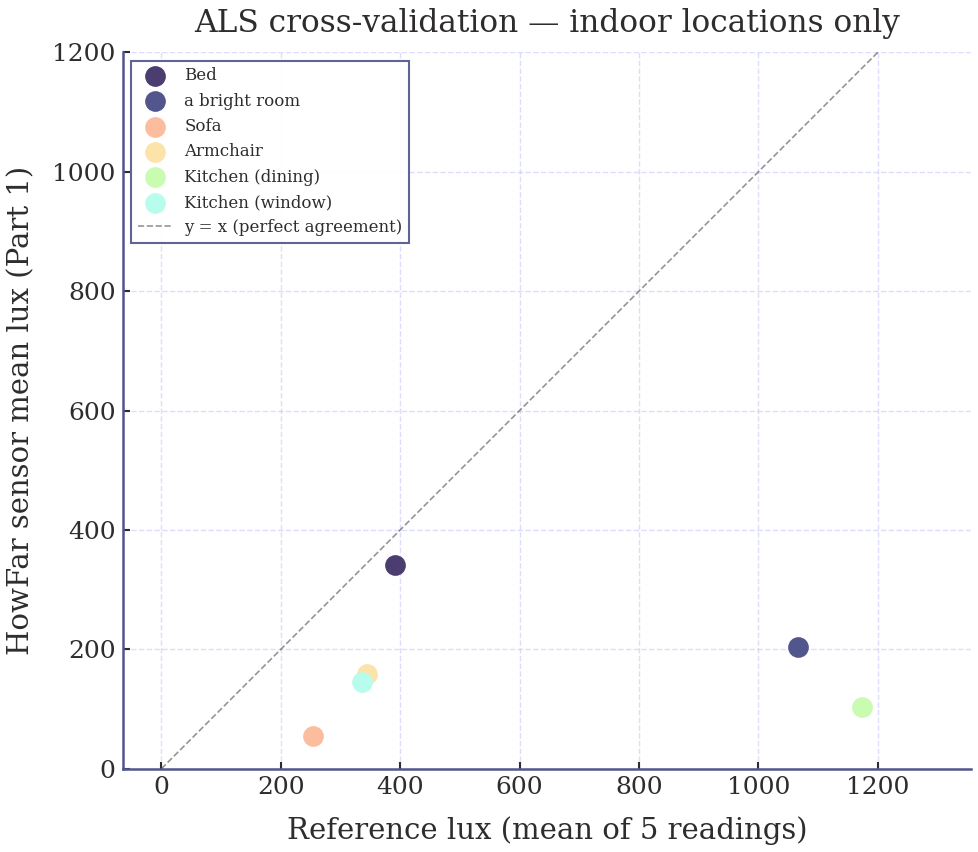

In [8]:
import matplotlib.patches as mpatches

BASE = '2026-05-25 '
segments = [
    # (label, p1_start, p1_end, ref_mean, p2_start, p2_end)
    ('Roof window',       '16:30:18', '16:32:00', 74640, '16:39:00', '16:41:00'),
    ('Bed',               '16:32:00', '16:33:00',   392, '16:41:00', '16:43:00'),
    ('a bright room',     '16:33:00', '16:35:00',  1066, '16:43:00', '16:45:00'), # Renamed Sister's room
    ('Sofa',              '16:35:00', '16:35:40',   254, '16:45:00', '16:47:00'),
    ('Armchair',          '16:35:40', '16:36:00',   344, '16:47:00', '16:49:00'),
    ('Kitchen (dining)',  '16:36:00', '16:37:00',  1174, '16:49:00', '16:51:00'),
    ('Kitchen (window)',  '16:37:00', '16:38:10',   336, '16:51:00', '16:53:43'),
]

seg_colors = SEG_COLORS[:7]

def ts(t): return pd.Timestamp(BASE + t)

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(df['datetime'], df['alx_lx'], color=C_HF, linewidth=0.7, alpha=0.85, zorder=2)

for i, (label, p1s, p1e, ref, p2s, p2e) in enumerate(segments):
    col = seg_colors[i]
    p1_start, p1_end = ts(p1s), ts(p1e)
    p2_start, p2_end = ts(p2s), ts(p2e)

    ax.axvspan(p1_start, p1_end, alpha=0.12, color=col, zorder=1)
    ax.axvspan(p2_start, p2_end, alpha=0.12, color=col, zorder=1)

    ref_plot = min(ref, 2500)
    ax.hlines(ref_plot, p1_start, p1_end, colors=col, linewidth=2.5, zorder=3,
              linestyles='--' if ref > 2500 else '-')

    ax.text(p1_start + (p1_end - p1_start) / 2, 2350, label,
            ha='center', va='bottom', fontsize=7, color=col, rotation=0)
    ax.text(p2_start + (p2_start - p2_start) / 2, 2350, label,
            ha='center', va='bottom', fontsize=7, color=col, rotation=0)

ax.axhline(55,   color=C_T,    linestyle=':', linewidth=0.9, alpha=0.6)
ax.axhline(300,  color='#FCBD9F', linestyle=':', linewidth=0.9, alpha=0.6)
ax.axhline(1000, color=C_OUT,  linestyle=':', linewidth=0.9, alpha=0.6)
ax.set_ylabel('Illuminance (lux)')
ax.set_xlabel('Time')
ax.set_title('HowFar ALS — annotated by location. Dashed coloured lines = reference meter mean (Part 1 only). Roof window ref (74,640 lux) capped at 2,500 for scale.')
ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.tight_layout()
plt.show()


indoor = segments[1:]

ref_means, sensor_means, labels_plot = [], [], []
for label, p1s, p1e, ref, _, _ in indoor:
    mask = (df['datetime'] >= ts(p1s)) & (df['datetime'] < ts(p1e))
    sensor_mean = df.loc[mask, 'alx_lx'].mean()
    ref_means.append(ref)
    sensor_means.append(sensor_mean)
    labels_plot.append(label)

fig, ax = plt.subplots(figsize=(8, 6))
for i, (rx, sy, lbl) in enumerate(zip(ref_means, sensor_means, labels_plot)):
    ax.scatter(rx, sy, color=seg_colors[i+1], s=80, zorder=3, label=lbl) # Added label to scatter
    # Removed: ax.annotate(lbl, (rx, sy), textcoords='offset points', xytext=(6, 4), fontsize=8)

max_val = max(max(ref_means), max(sensor_means)) * 1.1
ax.plot([0, max_val], [0, max_val], color='#2E2C2C', linestyle='--', linewidth=0.8, alpha=0.5, label='y = x (perfect agreement)')
ax.set_xlabel('Reference lux (mean of 5 readings)')
ax.set_ylabel('HowFar sensor mean lux (Part 1)')
ax.set_title('ALS cross-validation — indoor locations only')
ax.set_ylim(bottom=0, top=1200)
ax.set_xticks([0, 200, 400, 600, 800, 1000, 1200])
ax.set_yticks([0, 200, 400, 600, 800, 1000, 1200]) # Added 1200 step to y-axis
ax.set_aspect('equal', adjustable='box') # Ensure x-axis width equals y-axis height
ax.legend(fontsize=8)
plt.tight_layout()
fig.savefig('figs/ch4/fig_4_als_ratio.pdf', bbox_inches='tight', dpi=300)
print('Saved: figs/ch4/fig_4_als_ratio.pdf')
plt.show()

## 2. Signal Cleaning
Filters out-of-range ToF values with rolling-mean imputation and reports per-segment replacement statistics.

In [9]:
SPIKE_THRESH = 300.0

df2 = df.copy()

df2['tof_cm'] = df2['tof_distance_mm'] / 10.0
invalid_zero  = (df2['tof_distance_mm'] == 0)
invalid_range = (~invalid_zero) & ((df2['tof_cm'] < DIST_MIN_CM) | (df2['tof_cm'] > DIST_MAX_CM))
invalid_mask  = invalid_zero | invalid_range
df2.loc[invalid_mask, 'tof_cm'] = np.nan
rolling_fill = df2['tof_cm'].rolling(window=121, min_periods=1, center=True).mean()
df2['tof_cm_clean'] = df2['tof_cm'].fillna(rolling_fill).fillna(df2['tof_cm'].mean())

prev_diff = df2['alx_lx'] - df2['alx_lx'].shift(1)
next_diff = df2['alx_lx'] - df2['alx_lx'].shift(-1)
spike_mask = (prev_diff > SPIKE_THRESH) & (next_diff > SPIKE_THRESH)
df2['alx_lx_clean'] = df2['alx_lx'].copy()
df2.loc[spike_mask, 'alx_lx_clean'] = (
    (df2['alx_lx'].shift(1) + df2['alx_lx'].shift(-1)) / 2
).loc[spike_mask]

dt2 = df2['timestamp'].diff().dropna()
assert (dt2 == 1).all(), "Sampling interval broken!"

print(f'Rows: {len(df2)}  |  Sampling interval preserved: {(dt2==1).all()}')
print()
print('--- Distance ---')
print(f'Invalid (zero):      {invalid_zero.sum()}  ({100*invalid_zero.mean():.1f}%)')
print(f'Invalid (out-range): {invalid_range.sum()}  ({100*invalid_range.mean():.1f}%)')
print(f'Total imputed:       {invalid_mask.sum()}  ({100*invalid_mask.mean():.1f}%)')
print(f'Remaining NaN:       {df2["tof_cm_clean"].isna().sum()}')
print()
print('--- Lux ---')
print(f'Spike threshold:     >{SPIKE_THRESH} lux above both neighbours')
print(f'Spikes detected:     {spike_mask.sum()} ({100*spike_mask.mean():.2f}%)')
if spike_mask.sum() > 0:
    print(f'Spike values:        {df2.loc[spike_mask, "alx_lx"].values.round(1)}')
    print(f'Replaced with:       {df2.loc[spike_mask, "alx_lx_clean"].values.round(1)}')
print()
print('Clean distance stats (cm):')
print(df2['tof_cm_clean'].describe().round(1))
print()
print('Clean lux stats:')
print(df2['alx_lx_clean'].describe().round(2))

Rows: 1406  |  Sampling interval preserved: True

--- Distance ---
Invalid (zero):      621  (44.2%)
Invalid (out-range): 8  (0.6%)
Total imputed:       629  (44.7%)
Remaining NaN:       0

--- Lux ---
Spike threshold:     >300.0 lux above both neighbours
Spikes detected:     10 (0.71%)
Spike values:        [1758.7  639.4 1040.6 1137.3 1475.8 1271.   814.7 1944.3  711.  1191.7]
Replaced with:       [498.6 105.4 499.5 464.  253.1 525.3 305.9 481.4 281.  108.5]

Clean distance stats (cm):
count    1406.0
mean       88.8
std        26.8
min        15.0
25%        73.1
50%        91.4
75%       107.2
max       137.9
Name: tof_cm_clean, dtype: float64

Clean lux stats:
count    1406.00
mean      204.55
std       191.89
min         5.76
25%        75.84
50%       160.48
75%       263.36
max      2201.60
Name: alx_lx_clean, dtype: float64


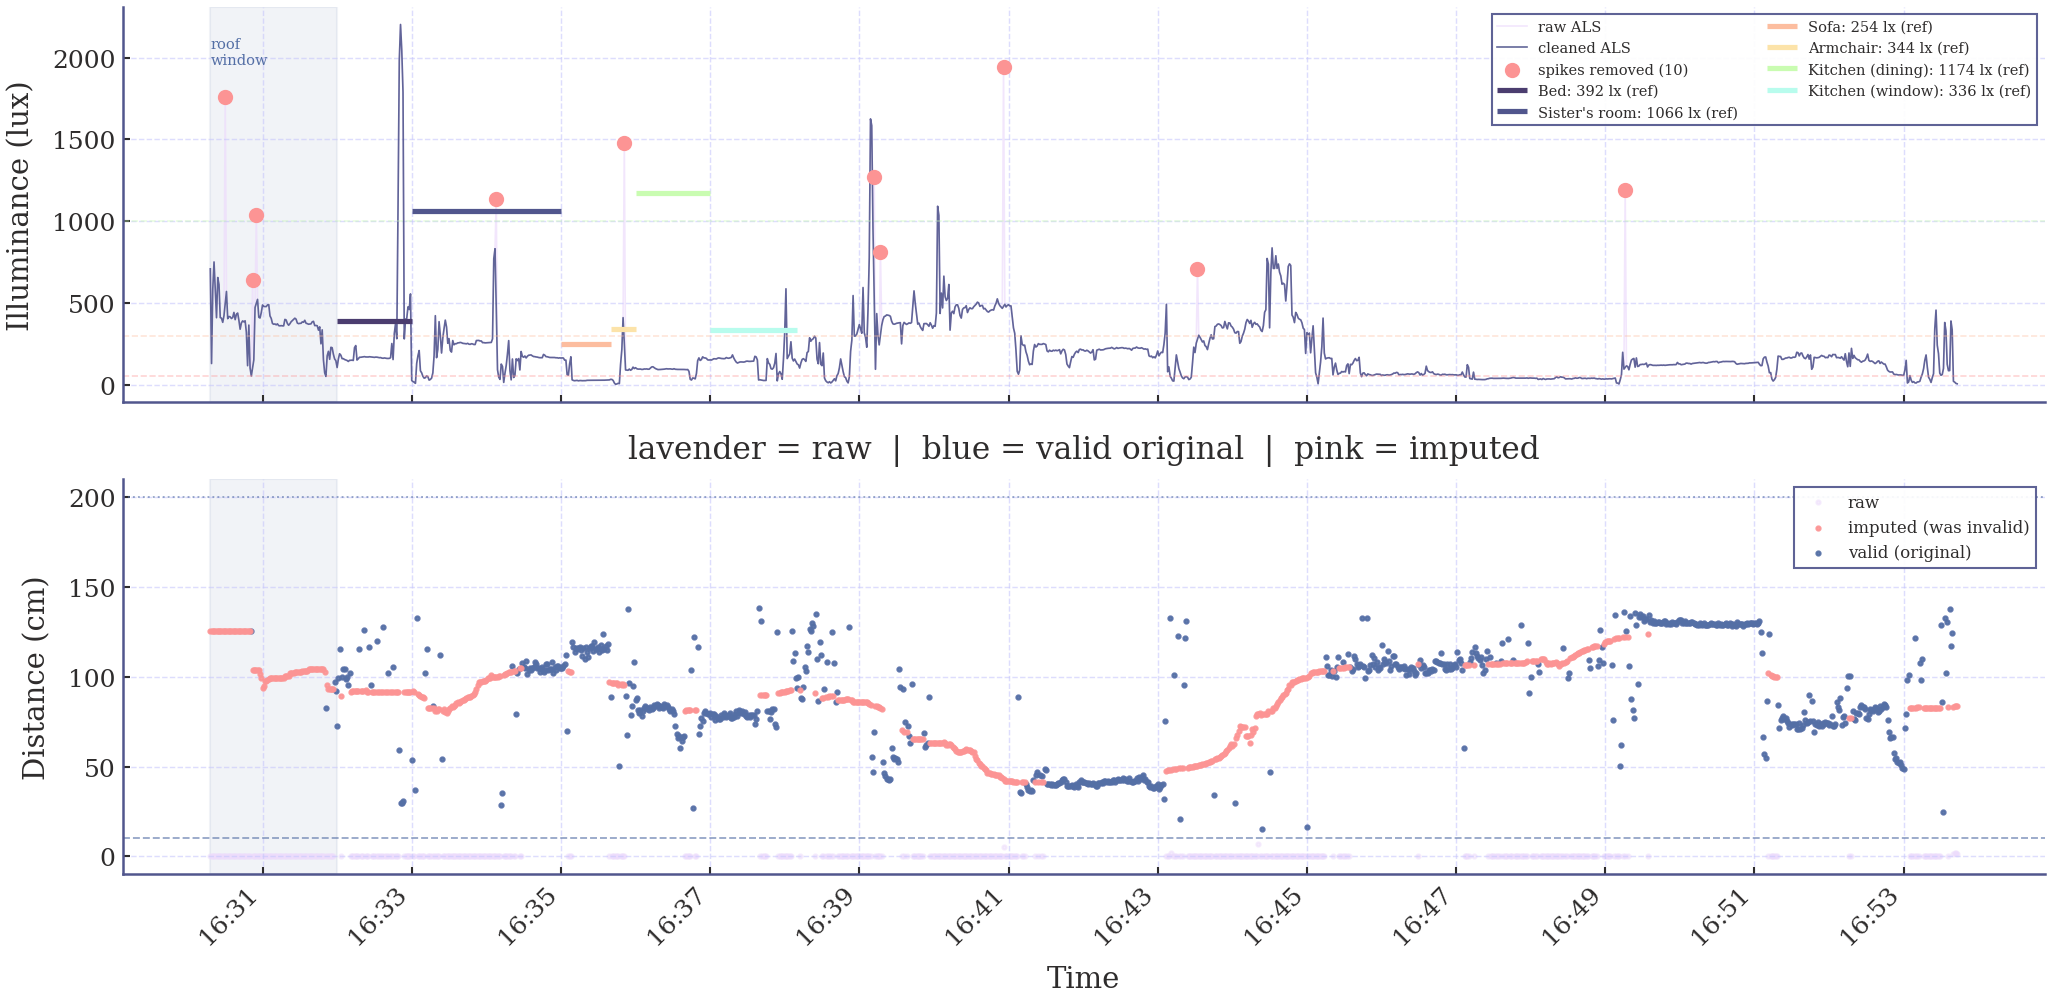

In [10]:
BASE = '2026-05-25 '
def ts(t): return pd.Timestamp(BASE + t)

segments_ref = [
    ('Bed',              '16:32:00', '16:33:00',  392, SEG_COLORS[1]),
    ("Sister's room",    '16:33:00', '16:35:00', 1066, SEG_COLORS[2]),
    ('Sofa',             '16:35:00', '16:35:40',  254, SEG_COLORS[3]),
    ('Armchair',         '16:35:40', '16:36:00',  344, SEG_COLORS[4]),
    ('Kitchen (dining)', '16:36:00', '16:37:00', 1174, SEG_COLORS[5]),
    ('Kitchen (window)', '16:37:00', '16:38:10',  336, SEG_COLORS[6]),
]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# --- ALS ---
ax1.plot(df2['datetime'], df2['alx_lx'],
         color='#EDDCFC', linewidth=0.8, alpha=0.7, zorder=1, label='raw ALS')
ax1.plot(df2['datetime'], df2['alx_lx_clean'],
         color=C_HF, linewidth=0.8, alpha=0.9, zorder=2, label='cleaned ALS')
if spike_mask.sum() > 0:
    ax1.scatter(df2.loc[spike_mask, 'datetime'], df2.loc[spike_mask, 'alx_lx'],
                c=C_T, s=40, zorder=4, label=f'spikes removed ({spike_mask.sum()})')
for label, p1s, p1e, ref, col in segments_ref:
    ax1.hlines(ref, ts(p1s), ts(p1e), colors=col, linewidth=2.5, zorder=3,
               label=f'{label}: {ref} lx (ref)')
for y, col, lbl in [(55,C_T,'55 lux'),(300,'#FCBD9F','300 lux'),(1000,C_OUT,'1000 lux')]:
    ax1.axhline(y, color=col, linestyle='--', linewidth=0.8, alpha=0.4)
ax1.set_ylabel('Illuminance (lux)')
ax1.legend(loc='upper right', fontsize=7, ncol=2)

ax2.scatter(df2['datetime'], df2['tof_distance_mm'] / 10.0,
            c='#EDDCFC', s=4, alpha=0.5, zorder=1, label='raw')
ax2.scatter(df2.loc[invalid_mask, 'datetime'], df2.loc[invalid_mask, 'tof_cm_clean'],
            c=C_T, s=4, alpha=0.9, zorder=3, label='imputed (was invalid)')
ax2.scatter(df2.loc[~invalid_mask, 'datetime'], df2.loc[~invalid_mask, 'tof_cm_clean'],
            c=C_S, s=4, alpha=0.9, zorder=2, label='valid (original)')
ax2.axhline(DIST_MIN_CM, color=C_S, linestyle='--', linewidth=0.9, alpha=0.6)
ax2.axhline(DIST_MAX_CM, color=C_S, linestyle=':', linewidth=0.9, alpha=0.6)
ax2.set_ylabel('Distance (cm)')
ax2.set_xlabel('Time')
ax2.set_title('lavender = raw  |  blue = valid original  |  pink = imputed')
ax2.legend(loc='upper right', fontsize=8)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

ax1.axvspan(ts('16:30:18'), ts('16:32:00'), color=SEG_COLORS[0], alpha=0.08, zorder=0)
ax1.text(ts('16:30:18'), ax1.get_ylim()[1] * 0.92, 'roof\nwindow',
         fontsize=7, color=SEG_COLORS[0], va='top')
ax2.axvspan(ts('16:30:18'), ts('16:32:00'), color=SEG_COLORS[0], alpha=0.08, zorder=0)

for ax in (ax1, ax2):
    ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

---

# Measurement 2 — Distance Validation (2026-05-26)

**Purpose:** Check how accurately the ToF sensor measures distance across its full range (10–200 cm), and whether the target surface material makes a difference. Two surfaces were tested: white cardboard and grey cloth.

**Sampling:** 5 s interval (measurementInterval = 5)

**Data file:** `distance validation 25.05.csv`

### Measurement Protocol — Distance Validation

Two parts, same distance sequence, different target surfaces. Each distance held for ~1 minute. Between parts: transition ≈ 18:09–18:12 (cardboard removed 18:09, device covered 18:10, Part 2 began 18:12). Session ended 18:25.

| Part | Surface | Distance (cm) | Start | End |
|------|---------|--------------|-------|-----|
| 1 | White cardboard | 10 | 17:58 | 17:59 |
| 1 | White cardboard | 20 | 17:59 | 18:00 |
| 1 | White cardboard | 30 | 18:00 | 18:01 |
| 1 | White cardboard | 40 | 18:01 | 18:02 |
| 1 | White cardboard | 50 | 18:02 | 18:03 |
| 1 | White cardboard | 70 | 18:03 | 18:04 |
| 1 | White cardboard | 90 | 18:04 | 18:05 |
| 1 | White cardboard | 110 | 18:05 | 18:06 |
| 1 | White cardboard | 130 | 18:06 | 18:07 |
| 1 | White cardboard | 150 | 18:07 | 18:08 |
| 1 | White cardboard | 200 | 18:08 | 18:09 |
| – | Transition | cardboard removed | 18:09 | 18:10 |
| – | Transition | device covered | 18:10 | 18:12 |
| 2 | Grey cloth | 10 | 18:12 | 18:13 |
| 2 | Grey cloth | 20 | 18:13 | 18:14 |
| 2 | Grey cloth | 30 | 18:14 | 18:15 |
| 2 | Grey cloth | 40 | 18:15 | 18:16 |
| 2 | Grey cloth | 50 | 18:16 | 18:17 |
| 2 | Grey cloth | 70 | 18:17 | 18:18 |
| 2 | Grey cloth | 90 | 18:18 | 18:19 |
| 2 | Grey cloth | 110 | 18:19 | 18:20 |
| 2 | Grey cloth | 130 | 18:20 | 18:21 |
| 2 | Grey cloth | 150 | 18:21 | 18:22 |
| 2 | Grey cloth | 200 | 18:22 | 18:23 |
| – | End | grey cloth removed | 18:23 | 18:24 |
| – | End | device covered / import | 18:24 | 18:25 |

## 1. Distance Sweep Analysis
Loads the 2026-05-26 distance validation sweep, computes valid-reading rates and absolute error by distance and surface material, and saves summary figures to `figs/ch5/`.

In [11]:
DIST_PATH = "/content/drive/MyDrive/Bachelor's Thesis/HowFar measurements/distance validation 25.05.csv"
SAMPLE_INTERVAL_M2 = 5  # seconds (measurementInterval = 5)

df_d = pd.read_csv(DIST_PATH, parse_dates=['datetime'])
df_d = df_d.sort_values('timestamp').reset_index(drop=True)

t_start_d = df_d['datetime'].iloc[0]
t_end_d   = df_d['datetime'].iloc[-1]
dur_d     = (t_end_d - t_start_d).total_seconds()
dt_d      = df_d['timestamp'].diff().dropna()
expected_rows_d = int(dur_d / SAMPLE_INTERVAL_M2) + 1

print(f'Rows: {len(df_d)}  |  Columns: {list(df_d.columns)}')
print(f'Start: {t_start_d}  →  End: {t_end_d}  ({dur_d/60:.1f} min)')
print(f'Expected rows at 5 s: {expected_rows_d}  |  Actual: {len(df_d)}')
print()
print(f'Sampling — min: {dt_d.min():.0f}s  max: {dt_d.max():.0f}s  mean: {dt_d.mean():.2f}s')
print(f'Exactly 5s: {(dt_d==5).sum()}/{len(dt_d)} ({100*(dt_d==5).mean():.1f}%)')
print(f'Gaps (dt>5s): {(dt_d>5).sum()}  |  Duplicates (dt=0s): {(dt_d==0).sum()}')
print()
df_d.info()
print()
print(df_d.describe().round(2))

Rows: 338  |  Columns: ['datetime', 'timestamp', 'alx_lx', 'tof_distance_mm']
Start: 2026-05-26 17:56:18  →  End: 2026-05-26 18:24:23  (28.1 min)
Expected rows at 5 s: 338  |  Actual: 338

Sampling — min: 5s  max: 5s  mean: 5.00s
Exactly 5s: 337/337 (100.0%)
Gaps (dt>5s): 0  |  Duplicates (dt=0s): 0

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 338 entries, 0 to 337
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   datetime         338 non-null    datetime64[ns]
 1   timestamp        338 non-null    int64         
 2   alx_lx           338 non-null    float64       
 3   tof_distance_mm  338 non-null    int64         
dtypes: datetime64[ns](1), float64(1), int64(2)
memory usage: 10.7 KB

                            datetime     timestamp  alx_lx  tof_distance_mm
count                            338  3.380000e+02  338.00           338.00
mean      2026-05-26 18:10:20.500000  1.779812e+09   

In [12]:
tof_d    = df_d['tof_distance_mm']
tof_d_cm = tof_d / 10.0
valid_d  = (tof_d_cm > DIST_MIN_CM) & (tof_d_cm <= DIST_MAX_CM)

print('=== ALS (lux) ===')
print(df_d['alx_lx'].describe().round(2))
print(f'Below {LOW_LIGHT_LUX} lux: {(df_d["alx_lx"]<LOW_LIGHT_LUX).sum()} ({100*(df_d["alx_lx"]<LOW_LIGHT_LUX).mean():.1f}%)')
print()
print('=== TOF (distance_mm) ===')
print(tof_d.describe().round(1))
print(f'Exactly 0 mm       : {(tof_d==0).sum()} ({100*(tof_d==0).mean():.1f}%)')
print(f'1–99 mm (rejected) : {((tof_d>0)&(tof_d<100)).sum()}')
print(f'100–2000 mm (valid): {valid_d.sum()} ({100*valid_d.mean():.1f}%)')
print(f'> 2000 mm          : {(tof_d>2000).sum()}')
print()
print('Valid TOF stats (cm):')
print(tof_d_cm[valid_d].describe().round(1))

=== ALS (lux) ===
count    338.00
mean      51.62
std       14.28
min        0.32
25%       45.84
50%       51.20
75%       53.44
max       98.24
Name: alx_lx, dtype: float64
Below 55.0 lux: 308 (91.1%)

=== TOF (distance_mm) ===
count     338.0
mean      422.6
std       425.4
min         0.0
25%        19.0
50%       321.5
75%       724.8
max      1357.0
Name: tof_distance_mm, dtype: float64
Exactly 0 mm       : 55 (16.3%)
1–99 mm (rejected) : 57
100–2000 mm (valid): 226 (66.9%)
> 2000 mm          : 0

Valid TOF stats (cm):
count    226.0
mean      62.7
std       38.0
min       10.7
25%       32.1
50%       51.4
75%       91.6
max      135.7
Name: tof_distance_mm, dtype: float64


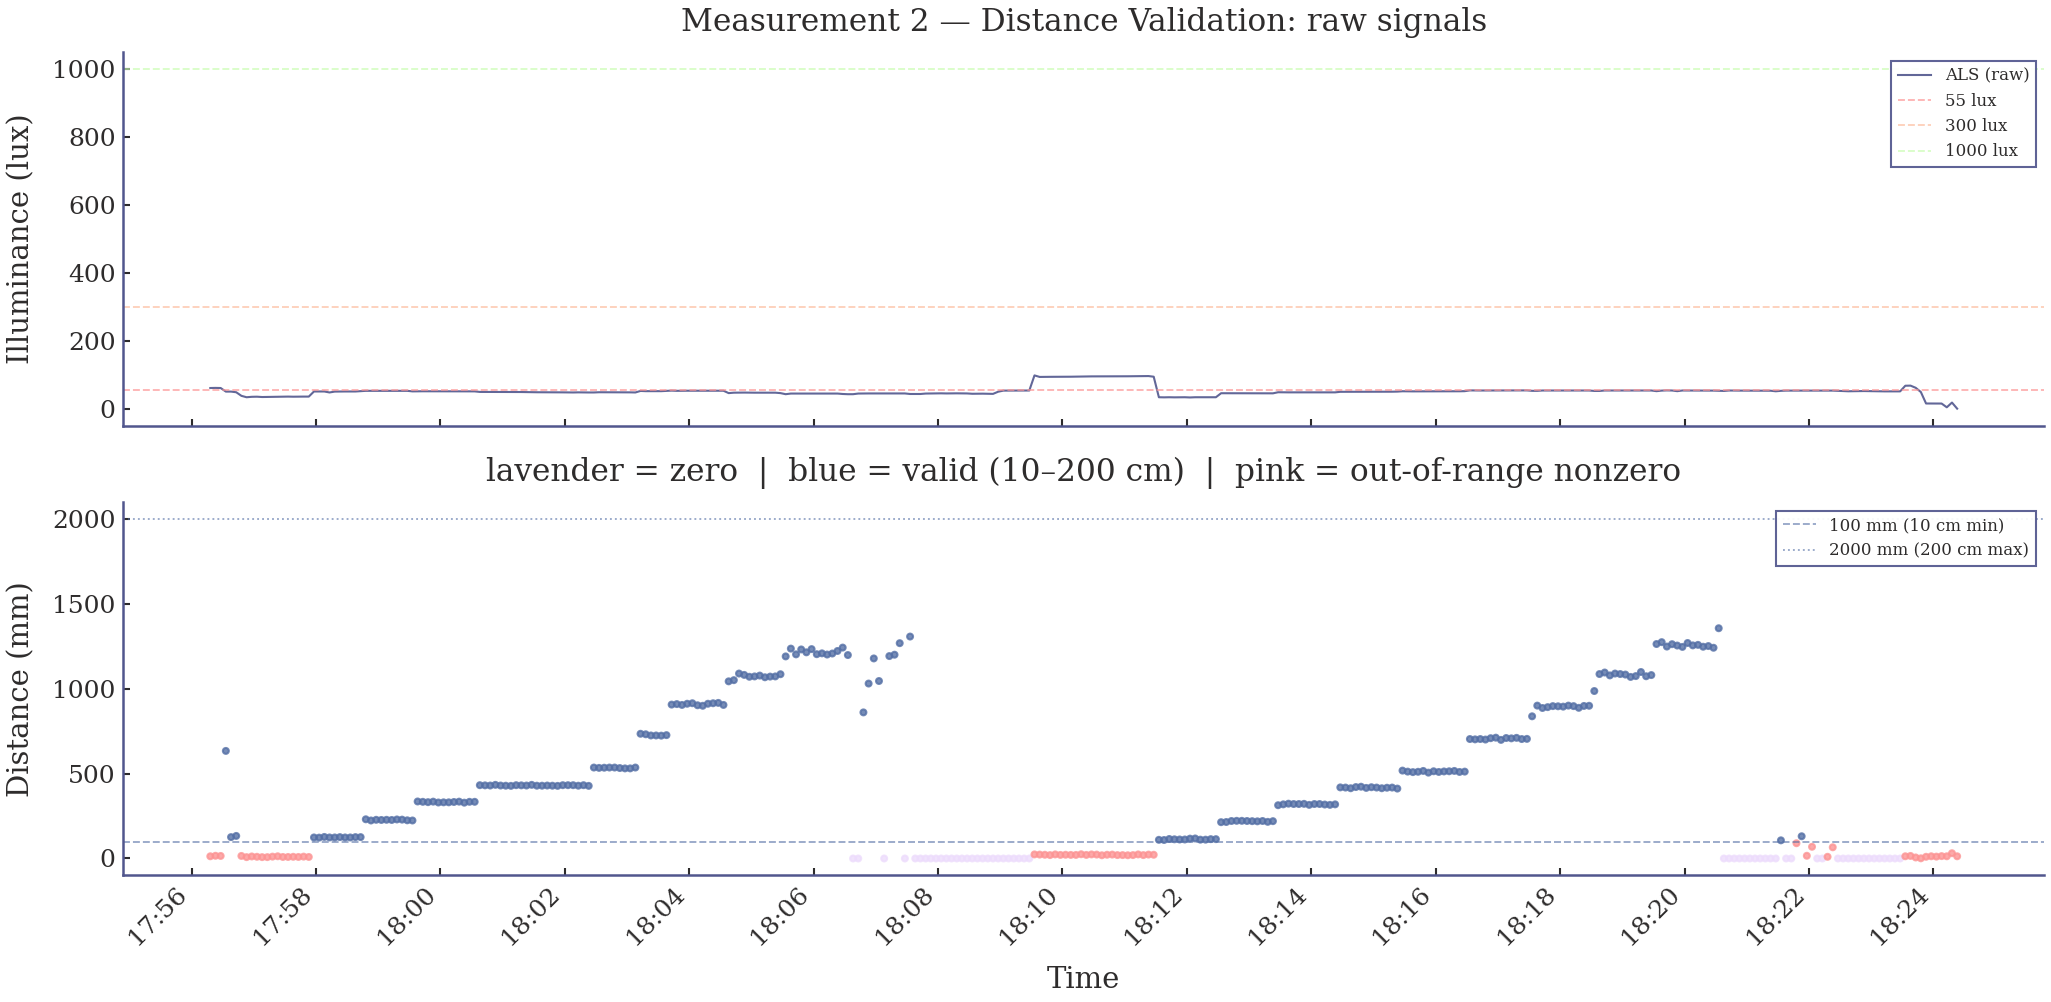

In [13]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
ax1.grid(False)
ax2.grid(False)

ax1.plot(df_d['datetime'], df_d['alx_lx'], color=C_HF, linewidth=1.0, alpha=0.9, label='ALS (raw)')
for y, col, lbl in [(55,C_T,'55 lux'),(300,'#FCBD9F','300 lux'),(1000,C_OUT,'1000 lux')]:
    ax1.axhline(y, color=col, linestyle='--', linewidth=0.9, alpha=0.7, label=lbl)
ax1.set_ylabel('Illuminance (lux)')
ax1.set_title('Measurement 2 — Distance Validation: raw signals')
ax1.legend(loc='upper right', fontsize=8)

colors_d = np.where(tof_d == 0, '#EDDCFC',
           np.where(valid_d, C_S, C_T))
ax2.scatter(df_d['datetime'], tof_d, c=colors_d, s=8, alpha=0.8)
ax2.axhline(100,  color=C_S, linestyle='--', linewidth=0.9, alpha=0.6, label='100 mm (10 cm min)')
ax2.axhline(2000, color=C_S, linestyle=':',  linewidth=0.9, alpha=0.6, label='2000 mm (200 cm max)')
ax2.set_ylabel('Distance (mm)')
ax2.set_xlabel('Time')
ax2.set_title('lavender = zero  |  blue = valid (10–200 cm)  |  pink = out-of-range nonzero')
ax2.legend(loc='upper right', fontsize=8)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax2.xaxis.set_major_locator(mdates.MinuteLocator(interval=2))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

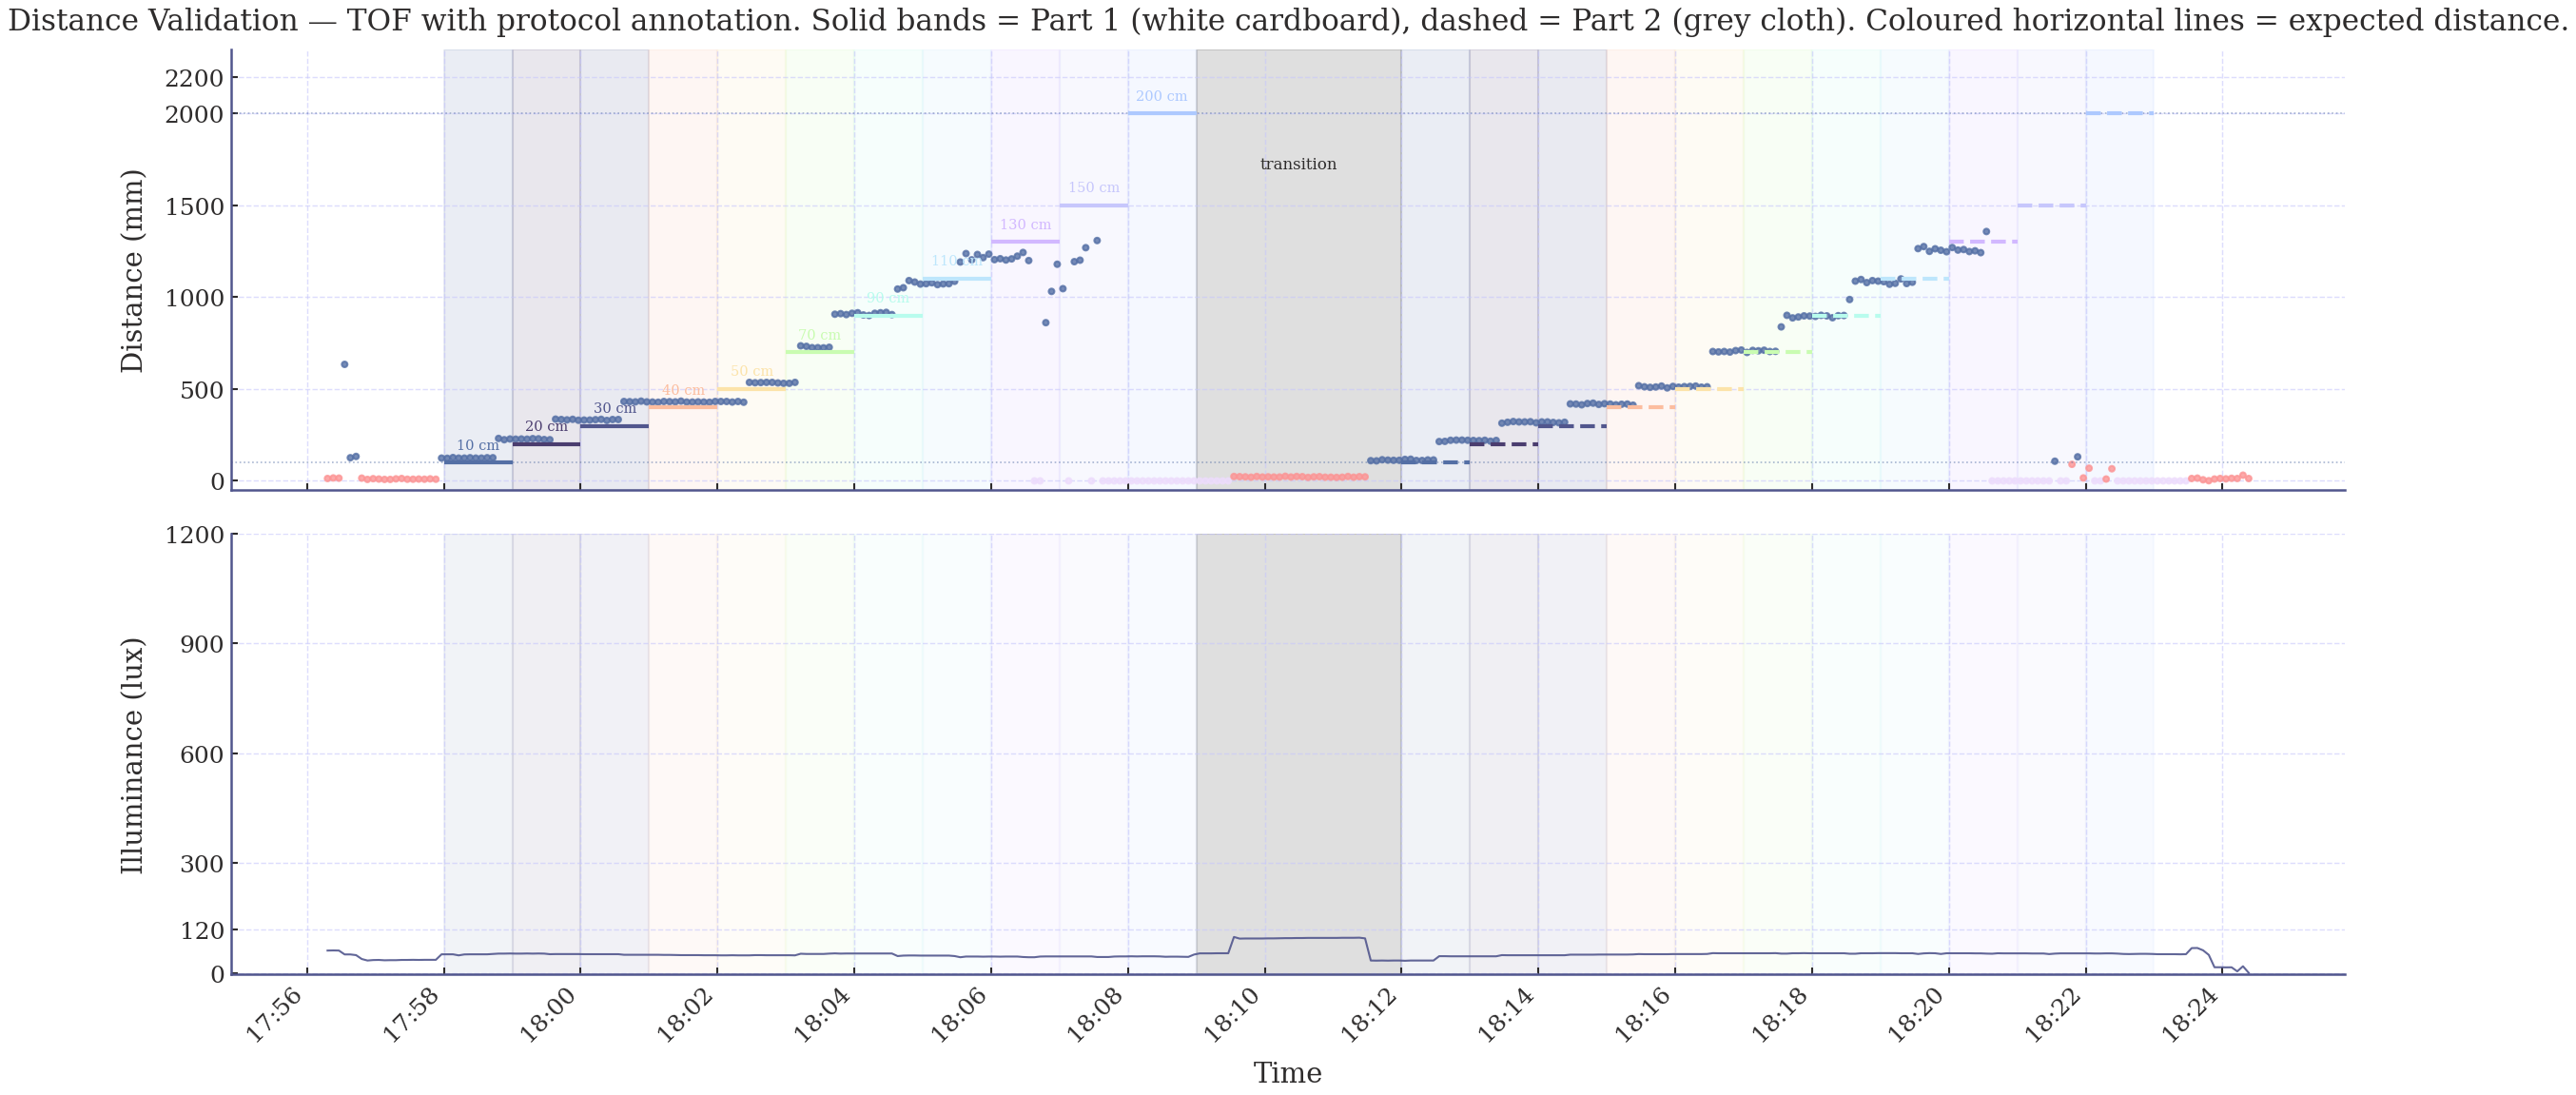

In [14]:
BASE_D = '2026-05-26 '
def ts_d(t): return pd.Timestamp(BASE_D + t)

p1_segments = [
    ('10 cm',  '17:58:00', '17:59:00',  100),
    ('20 cm',  '17:59:00', '18:00:00',  200),
    ('30 cm',  '18:00:00', '18:01:00',  300),
    ('40 cm',  '18:01:00', '18:02:00',  400),
    ('50 cm',  '18:02:00', '18:03:00',  500),
    ('70 cm',  '18:03:00', '18:04:00',  700),
    ('90 cm',  '18:04:00', '18:05:00',  900),
    ('110 cm', '18:05:00', '18:06:00', 1100),
    ('130 cm', '18:06:00', '18:07:00', 1300),
    ('150 cm', '18:07:00', '18:08:00', 1500),
    ('200 cm', '18:08:00', '18:09:00', 2000),
]
p2_segments = [
    ('10 cm',  '18:12:00', '18:13:00',  100),
    ('20 cm',  '18:13:00', '18:14:00',  200),
    ('30 cm',  '18:14:00', '18:15:00',  300),
    ('40 cm',  '18:15:00', '18:16:00',  400),
    ('50 cm',  '18:16:00', '18:17:00',  500),
    ('70 cm',  '18:17:00', '18:18:00',  700),
    ('90 cm',  '18:18:00', '18:19:00',  900),
    ('110 cm', '18:19:00', '18:20:00', 1100),
    ('130 cm', '18:20:00', '18:21:00', 1300),
    ('150 cm', '18:21:00', '18:22:00', 1500),
    ('200 cm', '18:22:00', '18:23:00', 2000),
]

seg_cols = SEG_COLORS[:len(p1_segments)]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

ax1.scatter(df_d['datetime'], tof_d, c=colors_d, s=8, alpha=0.8, zorder=2, label='raw TOF')
for i, (lbl, s, e, ref_mm) in enumerate(p1_segments):
    col = seg_cols[i]
    ax1.axvspan(ts_d(s), ts_d(e), alpha=0.12, color=col, zorder=1)
    ax1.hlines(ref_mm, ts_d(s), ts_d(e), colors=col, linewidth=2.0, linestyles='-', zorder=3)
    ax1.text(ts_d(s) + (ts_d(e)-ts_d(s))/2, ref_mm + 60, lbl,
             ha='center', va='bottom', fontsize=7, color=col)
for i, (lbl, s, e, ref_mm) in enumerate(p2_segments):
    col = seg_cols[i]
    ax1.axvspan(ts_d(s), ts_d(e), alpha=0.12, color=col, zorder=1)
    ax1.hlines(ref_mm, ts_d(s), ts_d(e), colors=col, linewidth=2.0, linestyles='--', zorder=3)
ax1.axvspan(ts_d('18:09:00'), ts_d('18:12:00'), color='#2E2C2C', alpha=0.15, zorder=1)
ax1.text(ts_d('18:10:30'), 1700, 'transition', ha='center', fontsize=8, color='#2E2C2C')
ax1.axhline(100,  color=C_S, linestyle=':', linewidth=0.8, alpha=0.5)
ax1.axhline(2000, color=C_S, linestyle=':', linewidth=0.8, alpha=0.5)
ax1.set_ylabel('Distance (mm)')
ax1.set_title('Distance Validation — TOF with protocol annotation.'
              ' Solid bands = Part 1 (white cardboard), dashed = Part 2 (grey cloth).'
              ' Coloured horizontal lines = expected distance.')

ax2.plot(df_d['datetime'], df_d['alx_lx'], color=C_HF, linewidth=1.0, alpha=0.9)
ax2.axvspan(ts_d('18:09:00'), ts_d('18:12:00'), color='#2E2C2C', alpha=0.15, zorder=1)
for i, (lbl, s, e, _) in enumerate(p1_segments):
    ax2.axvspan(ts_d(s), ts_d(e), alpha=0.08, color=seg_cols[i], zorder=1)
for i, (lbl, s, e, _) in enumerate(p2_segments):
    ax2.axvspan(ts_d(s), ts_d(e), alpha=0.08, color=seg_cols[i], zorder=1)
ax2.set_ylabel('Illuminance (lux)')
ax2.set_xlabel('Time')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax2.xaxis.set_major_locator(mdates.MinuteLocator(interval=2))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')
# Extra y-axis reference ticks
ax1.set_yticks([0, 500, 1000, 1500, 2000, 2200])
ax1.set_ylim(bottom=-50, top=2350)
ax2.set_yticks([0, 120, 300, 600, 900, 1200])
plt.tight_layout()
plt.show()

In [15]:
def analyse_segments(segments, label):
    print(f'=== {label} ===')
    header = f"{'Expected':<12} {'N reads':<10} {'Valid':<8} {'Valid %':<9} {'Zero %':<9} {'Median (mm)':<14} {'Error (mm)':<12} {'Error (cm)'}"
    print(header)
    print('-' * 85)
    rows = []
    for lbl, s, e, ref_mm in segments:
        mask = (df_d['datetime'] >= ts_d(s)) & (df_d['datetime'] < ts_d(e))
        seg  = df_d.loc[mask, 'tof_distance_mm']
        n      = len(seg)
        n_valid = ((seg >= 100) & (seg <= 2000)).sum()
        n_zero  = (seg == 0).sum()
        valid_v = seg[(seg >= 100) & (seg <= 2000)]
        med     = valid_v.median() if len(valid_v) > 0 else float('nan')
        err_mm  = med - ref_mm if not pd.isna(med) else float('nan')
        err_cm  = err_mm / 10   if not pd.isna(err_mm) else float('nan')
        print(f'{lbl:<12} {n:<10} {n_valid:<8} {100*n_valid/n if n>0 else 0:<9.1f} '
              f'{100*n_zero/n if n>0 else 0:<9.1f} {med:<14.1f} {err_mm:<12.1f} {err_cm:.1f}')
        rows.append({'surface': label, 'expected_cm': ref_mm/10, 'n': n,
                     'n_valid': n_valid, 'n_zero': n_zero, 'median_mm': med, 'error_mm': err_mm})
    print()
    return rows

rows_p1 = analyse_segments(p1_segments, 'Part 1: White Cardboard')
rows_p2 = analyse_segments(p2_segments, 'Part 2: Grey Cloth')

=== Part 1: White Cardboard ===
Expected     N reads    Valid    Valid %   Zero %    Median (mm)    Error (mm)   Error (cm)
-------------------------------------------------------------------------------------
10 cm        12         12       100.0     0.0       126.0          26.0         2.6
20 cm        12         12       100.0     0.0       229.5          29.5         3.0
30 cm        12         12       100.0     0.0       334.5          34.5         3.5
40 cm        12         12       100.0     0.0       429.5          29.5         3.0
50 cm        12         12       100.0     0.0       532.0          32.0         3.2
70 cm        12         12       100.0     0.0       729.5          29.5         3.0
90 cm        12         12       100.0     0.0       916.0          16.0         1.6
110 cm       12         12       100.0     0.0       1138.5         38.5         3.9
130 cm       12         10       83.3      16.7      1203.0         -97.0        -9.7
150 cm       12         

Saved: figs/ch5/fig_5_dist_valid_rate_a.pdf


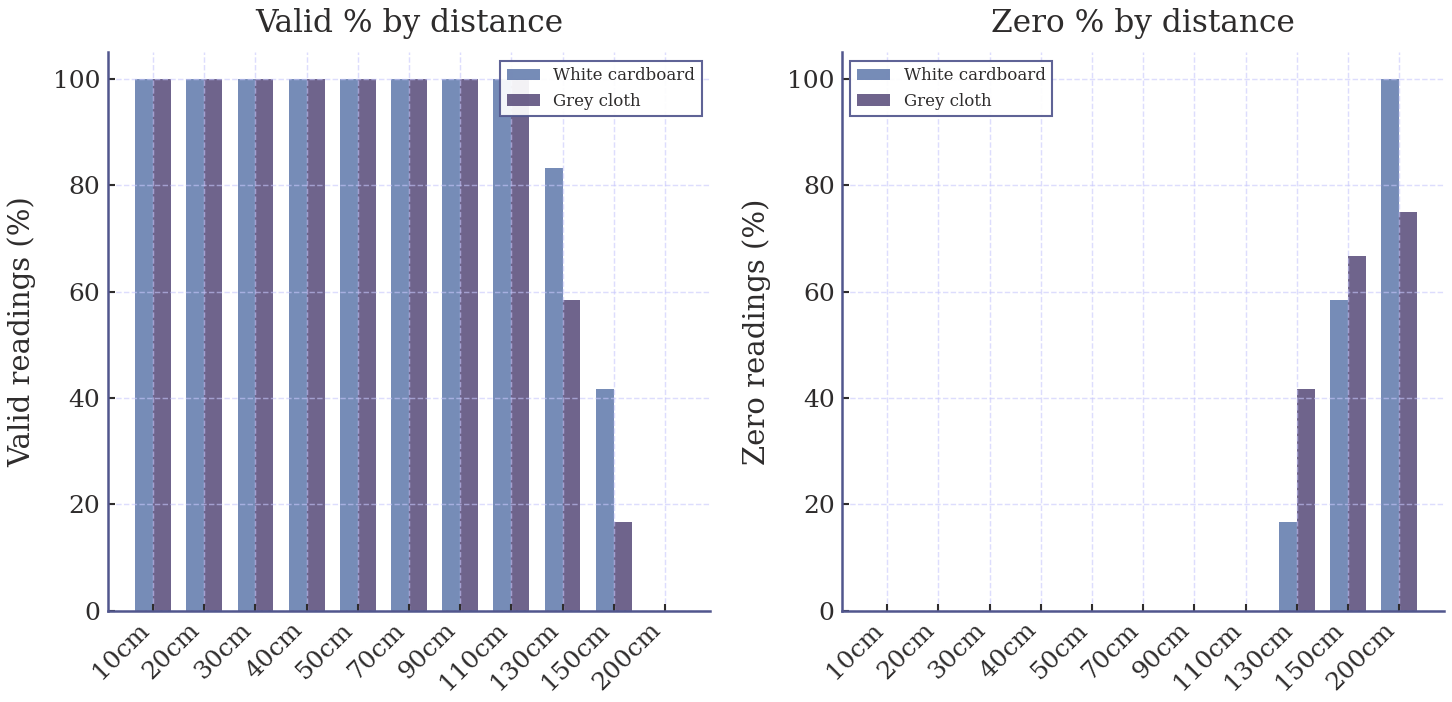

Saved: figs/ch5/fig_5_dist_valid_rate_b.pdf


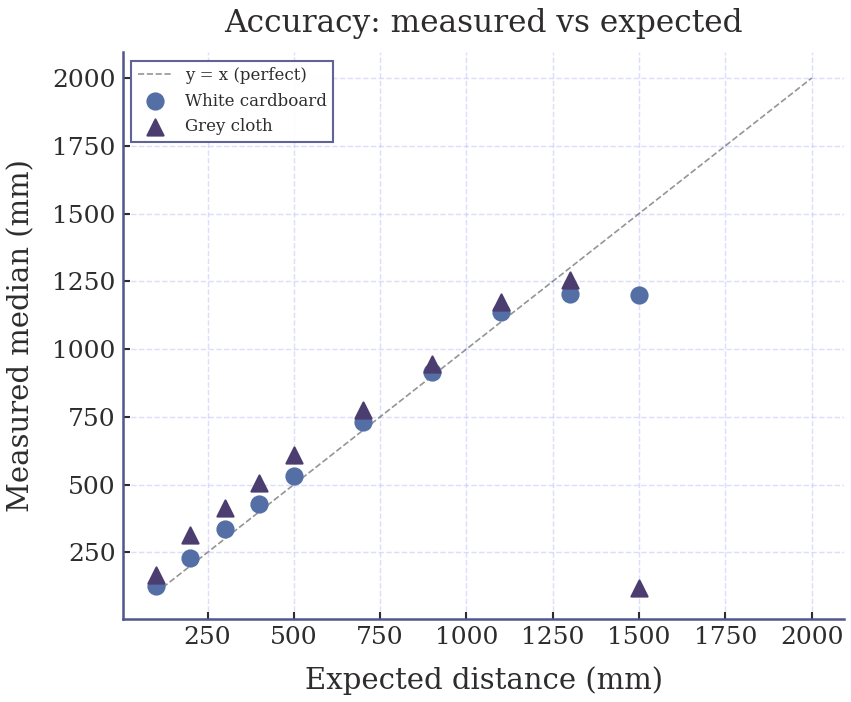

In [16]:
df_p1 = pd.DataFrame(rows_p1)
df_p2 = pd.DataFrame(rows_p2)

# Figure 1: Valid % and Zero % by distance
fig1, axes1 = plt.subplots(1, 2, figsize=(10, 5))

w = 0.35
x = np.arange(len(df_p1))

ax = axes1[0]
ax.bar(x - w/2, df_p1['n_valid']/df_p1['n']*100, w, label='White cardboard', color=C_S, alpha=0.8)
ax.bar(x + w/2, df_p2['n_valid']/df_p2['n']*100, w, label='Grey cloth',      color='#4B3D6F', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels([f'{int(r)}cm' for r in df_p1['expected_cm']], rotation=45, ha='right')
ax.set_ylabel('Valid readings (%)')
ax.set_title('Valid % by distance')
ax.legend(fontsize=8)

ax = axes1[1]
ax.bar(x - w/2, df_p1['n_zero']/df_p1['n']*100, w, label='White cardboard', color=C_S, alpha=0.8)
ax.bar(x + w/2, df_p2['n_zero']/df_p2['n']*100, w, label='Grey cloth',      color='#4B3D6F', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels([f'{int(r)}cm' for r in df_p1['expected_cm']], rotation=45, ha='right')
ax.set_ylabel('Zero readings (%)')
ax.set_title('Zero % by distance')
ax.legend(fontsize=8)

plt.tight_layout()
fig1.savefig('figs/ch5/fig_5_dist_valid_rate_a.pdf', bbox_inches='tight', dpi=300)
print('Saved: figs/ch5/fig_5_dist_valid_rate_a.pdf')
plt.show()

# Figure 2: Accuracy: measured vs expected
fig2, ax = plt.subplots(1, 1, figsize=(6, 5)) # Changed to single subplot figure

exp = df_p1['expected_cm'].values * 10  # mm
ax.plot(exp, exp, color='#2E2C2C', linestyle='--', linewidth=0.8, alpha=0.5, label='y = x (perfect)')
ax.scatter(exp, df_p1['median_mm'], color=C_S, s=60, label='White cardboard', zorder=3)
ax.scatter(exp, df_p2['median_mm'], color='#4B3D6F', s=60, marker='^', label='Grey cloth', zorder=3)
ax.set_xlabel('Expected distance (mm)')
ax.set_ylabel('Measured median (mm)')
ax.set_title('Accuracy: measured vs expected')
ax.legend(fontsize=8)

plt.tight_layout()
fig2.savefig('figs/ch5/fig_5_dist_valid_rate_b.pdf', bbox_inches='tight', dpi=300)
print('Saved: figs/ch5/fig_5_dist_valid_rate_b.pdf')
plt.show()

---

# Measurement 3 — Controlled ALS Geometry Test (2026-05-26)

**Purpose:** Test how the position of the light source relative to the sensor affects ALS accuracy. Both HowFar and the Sonel LXP-1 were kept stationary while four different lighting conditions were tested — ceiling lamp, flashlight pointed directly at the sensor, direct sunlight through a window, and indirect sunlight.

**Sampling:** 5 s interval (measurementInterval = 5)

**Data file:** `controlled ALS test 25.05.csv`

**Note:** Between conditions the device was covered with a thin white cloth during relocation, which may not have blocked all ambient light. Data recorded during transitions should not be used for analysis.

### Measurement Protocol — Controlled ALS Test

| Condition | Light source | Sensor orientation | Time | Ref. lux (5 readings) | Ref. mean |
|-----------|-------------|-------------------|------|----------------------|-----------|
| a | Ceiling lamp (overhead) | Upward / gaze-forward | 18:32–18:34 | 74, 73, 74, 73, 73 | 73.4 |
| b | Flashlight (frontal, directed at ALS) | Directly at ALS sensor | 18:35–18:37 | 103, 104, 103, 103, 104 | 103.4 |
| c | Window (direct sunlight) | Facing window — direct rays | 18:39–18:41 | 69500, 68700, 67900, 66900, 65000 | 67600 |
| d | Window (indirect) | Facing away — no direct rays | 18:42–18:44 | 769, 778, 768, 765, 780 | 772 |

Session ended 18:45 (device covered + import). Reference units: lux for conditions a, b, d; lux for c (values originally noted in klux, converted ×1000 here: 69.5 klux → 69500 lux, etc.).

## 1. Geometry Test Analysis
Loads the 2026-05-26 controlled ALS geometry test, plots ALS readings across four lighting conditions, and tabulates mean readings, error, and NRS tier per condition.

In [17]:
ALS_PATH = "/content/drive/MyDrive/Bachelor's Thesis/HowFar measurements/controlled ALS test 25.05.csv"
SAMPLE_INTERVAL_M3 = 5  # seconds

df_a = pd.read_csv(ALS_PATH, parse_dates=['datetime'])
df_a = df_a.sort_values('timestamp').reset_index(drop=True)

t_start_a = df_a['datetime'].iloc[0]
t_end_a   = df_a['datetime'].iloc[-1]
dur_a     = (t_end_a - t_start_a).total_seconds()
dt_a      = df_a['timestamp'].diff().dropna()
expected_rows_a = int(dur_a / SAMPLE_INTERVAL_M3) + 1

print(f'Rows: {len(df_a)}  |  Columns: {list(df_a.columns)}')
print(f'Start: {t_start_a}  →  End: {t_end_a}  ({dur_a/60:.1f} min)')
print(f'Expected rows at 5 s: {expected_rows_a}  |  Actual: {len(df_a)}')
print()
print(f'Sampling — min: {dt_a.min():.0f}s  max: {dt_a.max():.0f}s  mean: {dt_a.mean():.2f}s')
print(f'Exactly 5s: {(dt_a==5).sum()}/{len(dt_a)} ({100*(dt_a==5).mean():.1f}%)')
print(f'Gaps (dt>5s): {(dt_a>5).sum()}  |  Duplicates (dt=0s): {(dt_a==0).sum()}')
print()
df_a.info()
print()
print(df_a.describe().round(2))

Rows: 168  |  Columns: ['datetime', 'timestamp', 'alx_lx', 'tof_distance_mm']
Start: 2026-05-26 18:31:09  →  End: 2026-05-26 18:45:04  (13.9 min)
Expected rows at 5 s: 168  |  Actual: 168

Sampling — min: 5s  max: 5s  mean: 5.00s
Exactly 5s: 167/167 (100.0%)
Gaps (dt>5s): 0  |  Duplicates (dt=0s): 0

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   datetime         168 non-null    datetime64[ns]
 1   timestamp        168 non-null    int64         
 2   alx_lx           168 non-null    float64       
 3   tof_distance_mm  168 non-null    int64         
dtypes: datetime64[ns](1), float64(1), int64(2)
memory usage: 5.4 KB

                            datetime     timestamp   alx_lx  tof_distance_mm
count                            168  1.680000e+02   168.00           168.00
mean      2026-05-26 18:38:06.500000  1.779813e+09  

In [18]:
tof_a    = df_a['tof_distance_mm']
tof_a_cm = tof_a / 10.0
valid_a  = (tof_a_cm > DIST_MIN_CM) & (tof_a_cm <= DIST_MAX_CM)

print('=== ALS (lux) ===')
print(df_a['alx_lx'].describe().round(2))
print(f'Below {LOW_LIGHT_LUX} lux  : {(df_a["alx_lx"]<LOW_LIGHT_LUX).sum()} '
      f'({100*(df_a["alx_lx"]<LOW_LIGHT_LUX).mean():.1f}%)')
print(f'Saturated (≥2200 lux): {(df_a["alx_lx"]>=2200).sum()} '
      f'({100*(df_a["alx_lx"]>=2200).mean():.1f}%)')
print(f'NaN: {df_a["alx_lx"].isna().sum()}  |  Negative: {(df_a["alx_lx"]<0).sum()}')
print()
print('=== TOF (distance_mm) ===')
print(tof_a.describe().round(1))
print(f'Exactly 0 mm       : {(tof_a==0).sum()} ({100*(tof_a==0).mean():.1f}%)')
print(f'100–2000 mm (valid): {valid_a.sum()} ({100*valid_a.mean():.1f}%)')
print(f'> 2000 mm          : {(tof_a>2000).sum()}')

=== ALS (lux) ===
count     168.00
mean     1005.12
std      2436.64
min         0.16
25%         6.22
50%       131.84
75%       651.68
max      9387.52
Name: alx_lx, dtype: float64
Below 55.0 lux  : 68 (40.5%)
Saturated (≥2200 lux): 16 (9.5%)
NaN: 0  |  Negative: 0

=== TOF (distance_mm) ===
count     168.0
mean      276.7
std       386.4
min         0.0
25%        11.0
50%        15.0
75%       392.5
max      1373.0
Name: tof_distance_mm, dtype: float64
Exactly 0 mm       : 27 (16.1%)
100–2000 mm (valid): 73 (43.5%)
> 2000 mm          : 0


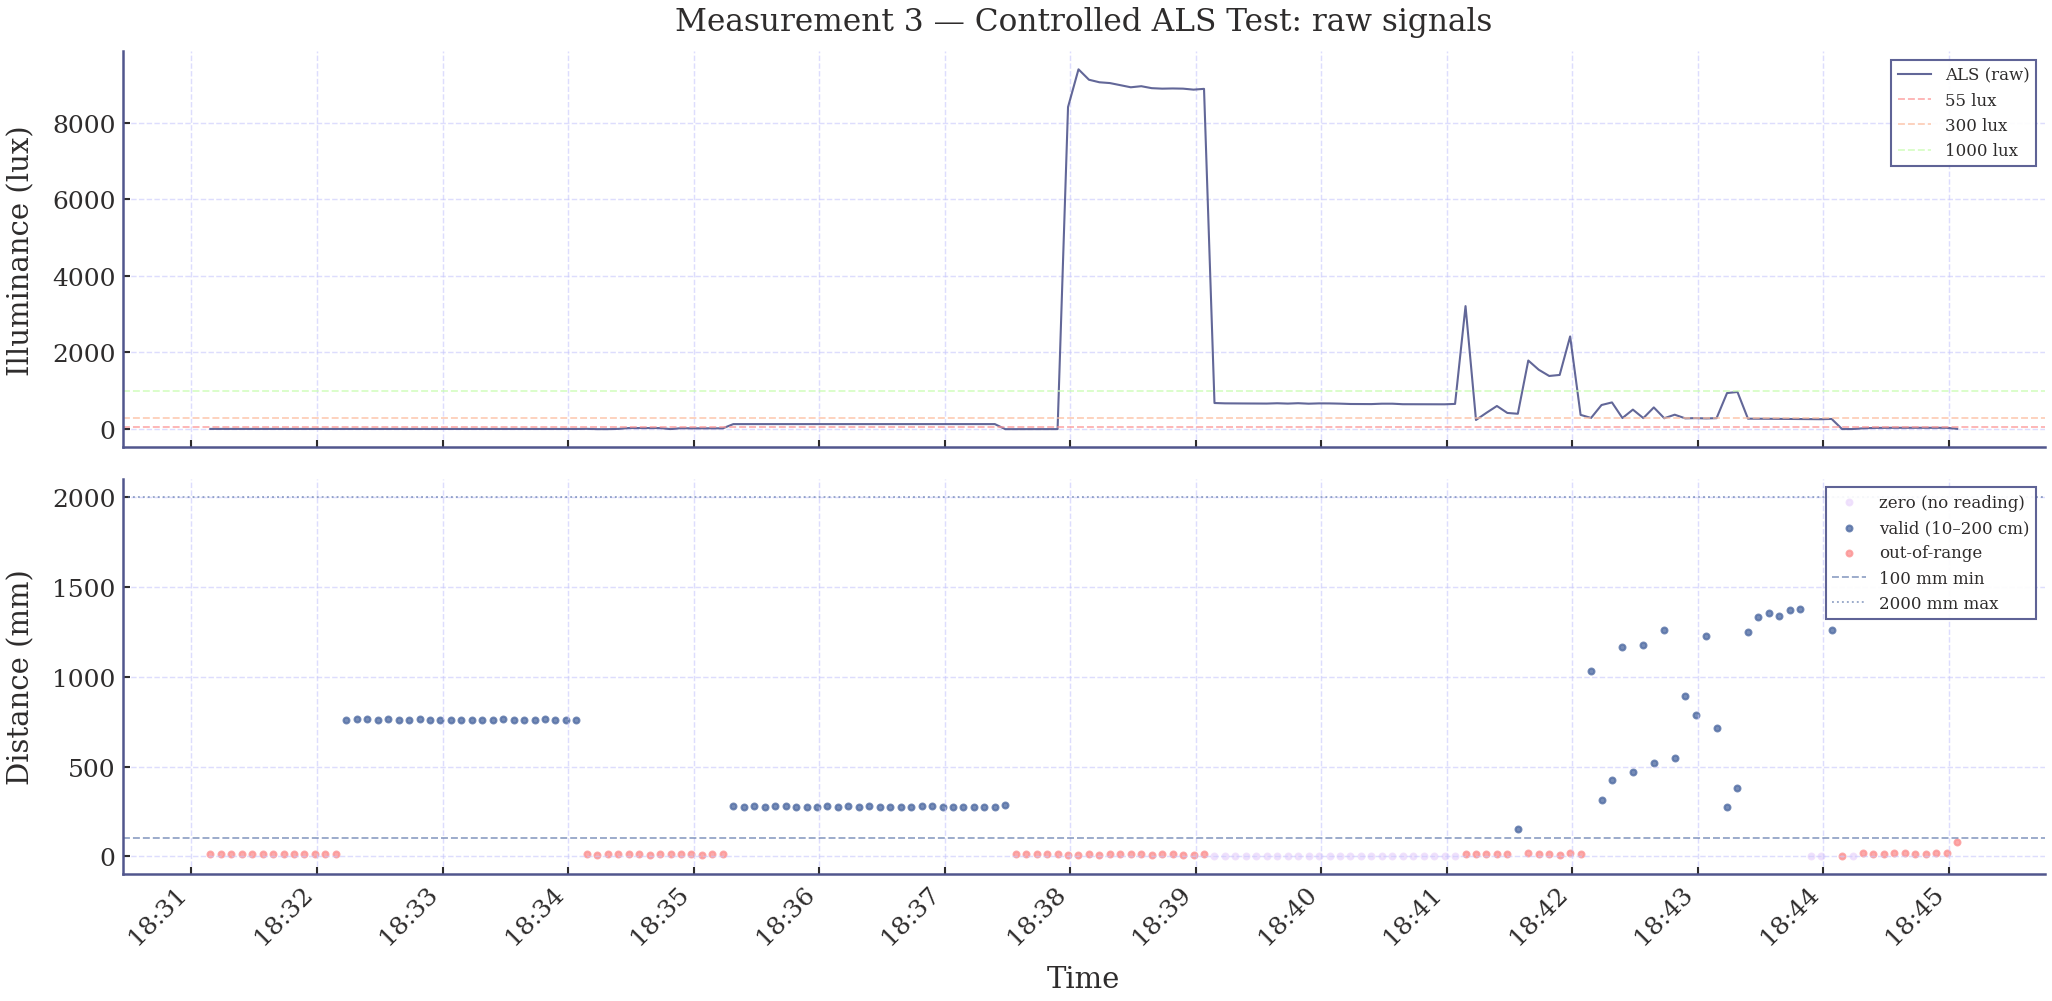

In [19]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

ax1.plot(df_a['datetime'], df_a['alx_lx'], color=C_HF, linewidth=1.0, alpha=0.9, label='ALS (raw)')
for y, col, lbl in [(55,C_T,'55 lux'),(300,'#FCBD9F','300 lux'),(1000,C_OUT,'1000 lux')]:
    ax1.axhline(y, color=col, linestyle='--', linewidth=0.9, alpha=0.7, label=lbl)
ax1.set_ylabel('Illuminance (lux)')
ax1.set_title('Measurement 3 — Controlled ALS Test: raw signals')
ax1.legend(loc='upper right', fontsize=8)

_zero_a = (tof_a == 0)
_oor_a  = (~_zero_a) & (~valid_a)
ax2.scatter(df_a.loc[_zero_a, 'datetime'], tof_a[_zero_a],  c='#EDDCFC', s=8, alpha=0.8, label='zero (no reading)')
ax2.scatter(df_a.loc[valid_a,  'datetime'], tof_a[valid_a], c=C_S,       s=8, alpha=0.8, label='valid (10–200 cm)')
ax2.scatter(df_a.loc[_oor_a,  'datetime'], tof_a[_oor_a],  c=C_T,       s=8, alpha=0.8, label='out-of-range')
ax2.axhline(100,  color=C_S, linestyle='--', linewidth=0.9, alpha=0.6, label='100 mm min')
ax2.axhline(2000, color=C_S, linestyle=':',  linewidth=0.9, alpha=0.6, label='2000 mm max')
ax2.set_ylabel('Distance (mm)')
ax2.set_xlabel('Time')
ax2.legend(loc='upper right', fontsize=8)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax2.xaxis.set_major_locator(mdates.MinuteLocator(interval=1))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

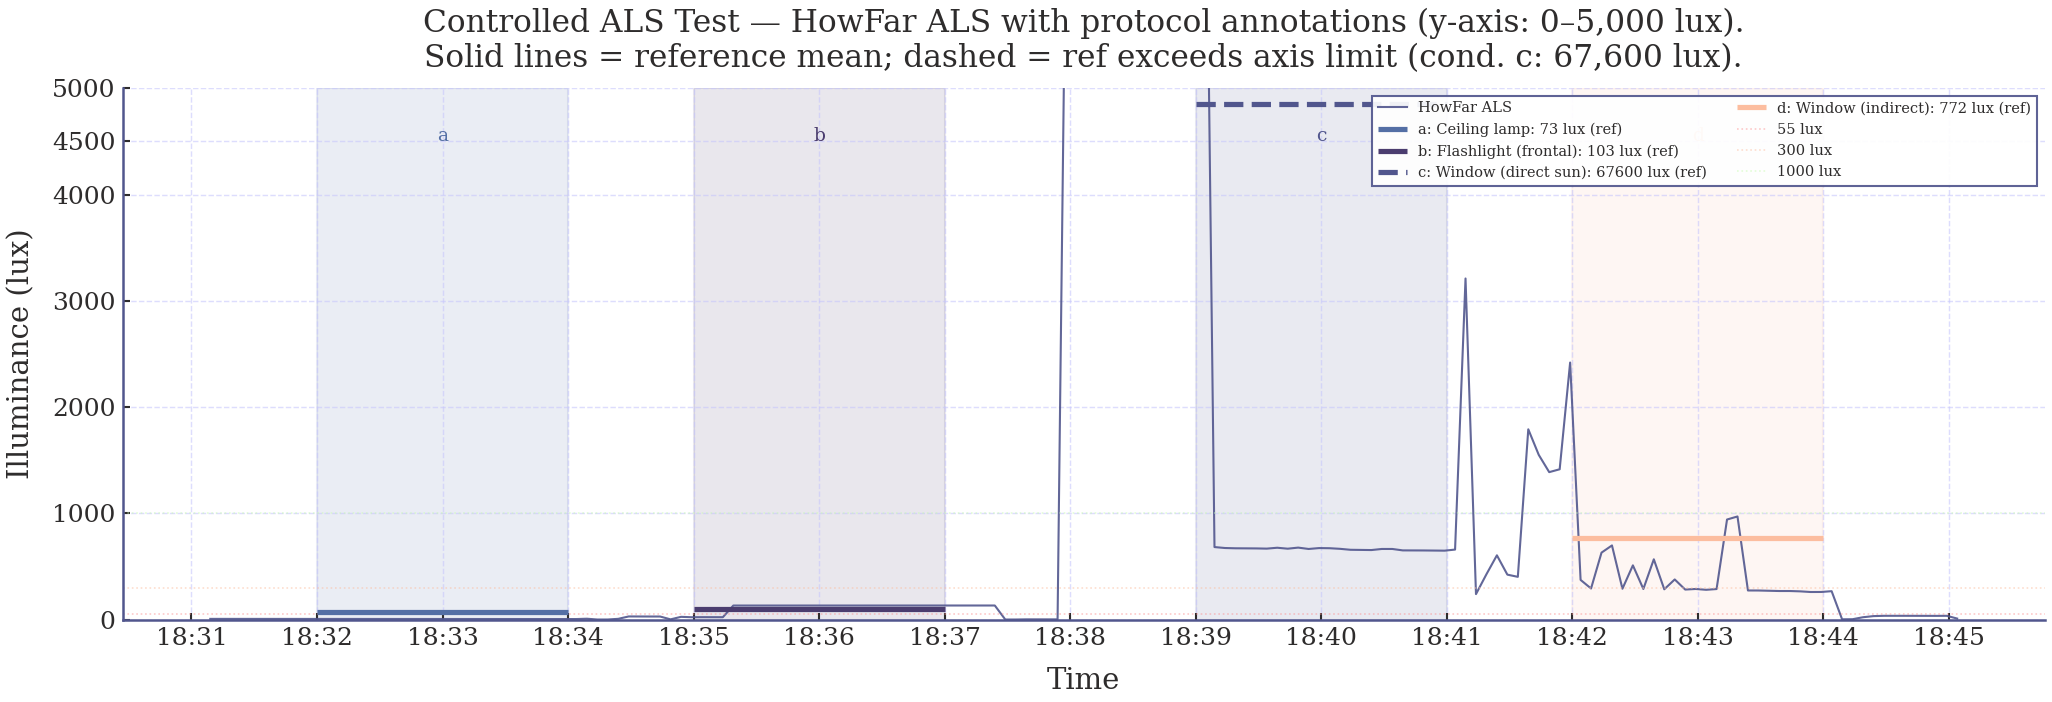

In [20]:
BASE_A = '2026-05-26 '
def ts_a(t): return pd.Timestamp(BASE_A + t)

conditions = [
    ('a: Ceiling lamp',         '18:32:00', '18:34:00',  73.4,  SEG_COLORS[0]),
    ('b: Flashlight (frontal)', '18:35:00', '18:37:00', 103.4,  SEG_COLORS[1]),
    ('c: Window (direct sun)',  '18:39:00', '18:41:00', 67600,  SEG_COLORS[2]),
    ('d: Window (indirect)',    '18:42:00', '18:44:00',  772,   SEG_COLORS[3]),
]

Y_MAX = 5000

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df_a['datetime'], df_a['alx_lx'], color=C_HF, linewidth=1.0,
        alpha=0.9, zorder=2, label='HowFar ALS')

for label, s, e, ref_lux, col in conditions:
    ax.axvspan(ts_a(s), ts_a(e), alpha=0.12, color=col, zorder=1)
    ref_plot = min(ref_lux, Y_MAX * 0.97)
    ls = '--' if ref_lux > Y_MAX else '-'
    ax.hlines(ref_plot, ts_a(s), ts_a(e), colors=col, linewidth=2.5,
              linestyles=ls, zorder=3,
              label=f'{label}: {ref_lux:.0f} lux (ref)')
    mid = ts_a(s) + (ts_a(e) - ts_a(s)) / 2
    ax.text(mid, Y_MAX * 0.90, label.split(':')[0],
            ha='center', fontsize=9, color=col)

for y, col2, lbl in [(55,C_T,'55 lux'),(300,'#FCBD9F','300 lux'),(1000,C_OUT,'1000 lux')]:
    ax.axhline(y, color=col2, linestyle=':', linewidth=0.8, alpha=0.5, label=lbl)

ax.set_ylim(0, Y_MAX)
ax.set_yticks([0, 1000, 2000, 3000, 4000, 4500, 5000])
ax.set_ylabel('Illuminance (lux)')
ax.set_xlabel('Time')
ax.set_title('Controlled ALS Test — HowFar ALS with protocol annotations (y-axis: 0–5,000 lux).\n'
             'Solid lines = reference mean; dashed = ref exceeds axis limit (cond. c: 67,600 lux).')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=1))
ax.legend(loc='upper right', fontsize=7, ncol=2)
plt.tight_layout()
plt.show()

In [21]:
def nrs_tier(lux):
    if lux <= 55:   return '≤55 (×1.5)'
    if lux <= 300:  return '≤300 (×1.0)'
    if lux <= 1000: return '≤1000 (×0.8)'
    if lux <= 3000: return '≤3000 (×0.5)'
    if lux <= 5000: return '≤5000 (×0.35)'
    return '>5000 (×0.2)'

print('=== ALS Cross-Validation — Controlled Geometry Test ===')
hdr = f"{'Condition':<32} {'Ref (lux)':<12} {'HF mean':<12} {'HF median':<12} {'Ratio ref/HF':<14} {'NRS tier (HF)'}"
print(hdr)
print('-' * 100)

results = []
for label, s, e, ref_lux, col in conditions:
    mask = (df_a['datetime'] >= ts_a(s)) & (df_a['datetime'] < ts_a(e))
    vals    = df_a.loc[mask, 'alx_lx']
    hf_mean = vals.mean()
    hf_med  = vals.median()
    ratio   = ref_lux / hf_mean if hf_mean > 0 else float('nan')
    print(f'{label:<32} {ref_lux:<12.1f} {hf_mean:<12.2f} {hf_med:<12.2f} {ratio:<14.2f} {nrs_tier(hf_mean)}')
    results.append({'condition': label, 'ref_lux': ref_lux,
                    'hf_mean': hf_mean, 'hf_med': hf_med, 'ratio': ratio})

print()
print('NRS tier assigned by HowFar vs correct tier (from reference):')
for r in results:
    correct  = nrs_tier(r['ref_lux'])
    assigned = nrs_tier(r['hf_mean'])
    match    = '✓' if correct == assigned else '✗  MISMATCH'
    print(f"  {r['condition']:<32}  ref={correct:<22} HF={assigned:<22} {match}")

=== ALS Cross-Validation — Controlled Geometry Test ===
Condition                        Ref (lux)    HF mean      HF median    Ratio ref/HF   NRS tier (HF)
----------------------------------------------------------------------------------------------------
a: Ceiling lamp                  73.4         4.89         4.80         15.00          ≤55 (×1.5)
b: Flashlight (frontal)          103.4        118.13       131.84       0.88           ≤300 (×1.0)
c: Window (direct sun)           67600.0      1006.21      666.24       67.18          ≤3000 (×0.5)
d: Window (indirect)             772.0        395.69       287.36       1.95           ≤1000 (×0.8)

NRS tier assigned by HowFar vs correct tier (from reference):
  a: Ceiling lamp                   ref=≤300 (×1.0)            HF=≤55 (×1.5)             ✗  MISMATCH
  b: Flashlight (frontal)           ref=≤300 (×1.0)            HF=≤300 (×1.0)            ✓
  c: Window (direct sun)            ref=>5000 (×0.2)           HF=≤3000 (×0.5)           ✗

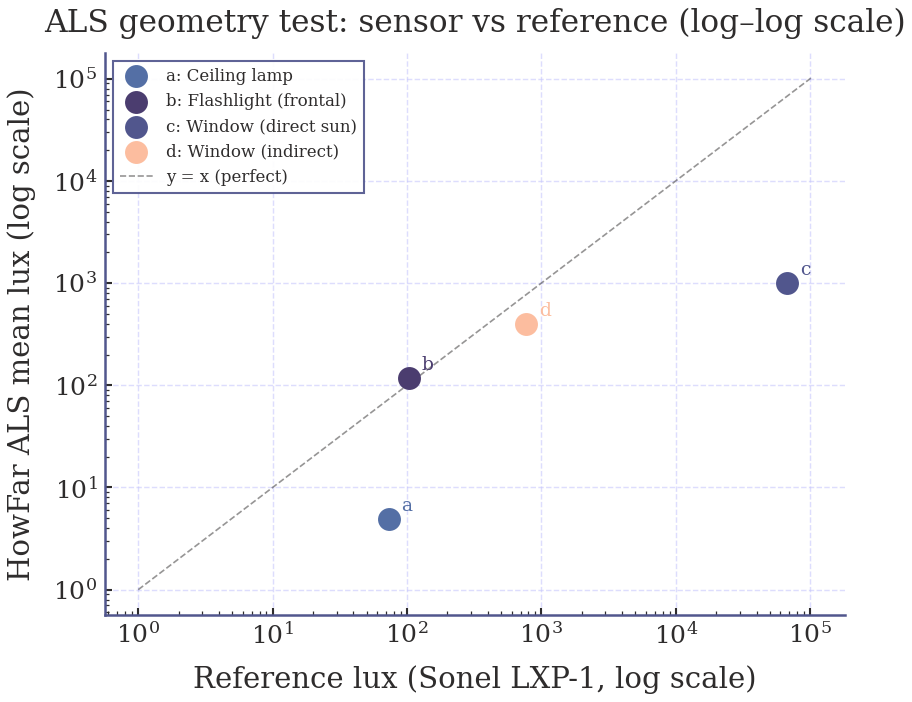

In [22]:
df_res = pd.DataFrame(results)
cols_c = [c[4] for c in conditions]

fig, ax = plt.subplots(figsize=(6, 5))
for i, row in df_res.iterrows():
    ax.scatter(row['ref_lux'], row['hf_mean'], color=cols_c[i], s=100, zorder=3,
               label=row['condition'])
    ax.annotate(row['condition'].split(':')[0], (row['ref_lux'], row['hf_mean']),
                textcoords='offset points', xytext=(6, 4), fontsize=9, color=cols_c[i])

max_val = max(df_res['ref_lux'].max(), df_res['hf_mean'].max()) * 1.5
ax.plot([1, max_val], [1, max_val], color='#2E2C2C', linestyle='--', linewidth=0.8, alpha=0.5, label='y = x (perfect)')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Reference lux (Sonel LXP-1, log scale)')
ax.set_ylabel('HowFar ALS mean lux (log scale)')
ax.set_title('ALS geometry test: sensor vs reference (log–log scale)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Summary & Findings
Key results across all three validation sessions.

1. All three measurements recorded clean data with no gaps and no duplicate timestamps. Measurement 1 (1 Hz, 25.05) produced 1,406 samples over 23.4 min. Measurement 2 (5 s interval, 26.05) produced 338 samples over 28.1 min. Measurement 3 (5 s interval, 26.05) produced 168 samples over 13.9 min.

2. The ALS sensor consistently underread the true lux value across all indoor locations in Measurement 1. The ratio between the reference meter and HowFar ranged from 1.15× to 11.31× across 6 locations. The likely reason for the mismatch is a structural difference between the two instruments: the Sonel LXP-1 uses a dome-shaped sensor that collects light from a wide solid angle, while HowFar's ALS is recessed behind a small aperture in the casing and is most sensitive to light arriving head-on. Given that this is a prototype, some degree of measurement error is expected.

3. The ToF sensor returned a value of 0 mm for 44% of all readings in Measurement 1. These are not true distance readings — the sensor uses 0 to signal that the measurement failed. Based on the distance validation sweep (Measurement 2), it becomes clear where this failure starts: the sensor begins returning zeros at around 130 cm and fails almost entirely at 200 cm.

4. In Measurement 1, the ALS signal reached a maximum of around 2,200 lux near a window. However, in Measurement 3 with direct sunlight facing the sensor, it reached 9,387 lux — well above that apparent ceiling. The 2,200 lux limit from Measurement 1 was therefore a geometry effect, not a hardware saturation limit.

5. From 10 to 110 cm, the ToF sensor performed reliably: all readings were valid (0% zeros) for both white cardboard and grey cloth targets. White cardboard produced a consistent overread of approximately +3 cm. Grey cloth produced a larger and consistent overread of approximately +10 cm, reflecting its lower IR reflectivity.

6. Reliability degraded significantly above 110 cm. With white cardboard, the valid rate dropped to 83% at 130 cm, 42% at 150 cm, and 0% at 200 cm. Grey cloth was worse at every step. The effective reliable range of the ToF sensor under these conditions is approximately 10–110 cm.

7. At 150 cm with grey cloth, the few readings that were classified as valid had a median of 119 mm — well below the expected 1,500 mm — suggesting the sensor locked onto a spurious nearby reflection. The measurement was conducted in an empty corridor with low ambient light; the exact cause of this anomaly is unclear.

8. In Measurement 3, the ceiling lamp produced the most severe ALS underread: HowFar read 4.9 lux against a reference of 73.4 lux (ratio ~15×). This is directly attributable to the geometry — a ceiling lamp illuminates from above, largely outside the sensor's sensitive cone, while the reference meter's dome collects that light efficiently.

9. When the flashlight was pointed directly at the sensor (simulating a phone or tablet held in front of the face), HowFar read 118 lux against a reference of 103 lux — essentially accurate and slightly over. This confirms that the sensor performs correctly when the light source is aligned with its optical axis.

10. Two of four conditions in Measurement 3 resulted in an incorrect NRS lux tier. The ceiling lamp was classified as ≤55 lux (tier weight ×1.5) when the correct tier was ≤300 lux (×1.0); direct sunlight was classified as ≤3,000 lux (×0.5) when the correct tier was >5,000 lux (×0.2). Both misclassifications push NRS upward: overhead indoor light — the most common scenario during near work — is the most affected, meaning NRS will be systematically higher than the true risk level would warrant. When the sensor geometry is well-matched to the light source (flashlight, indirect window light), tier assignment was correct.

